In [2]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import numpy as np
import matplotlib as mpl
import pandas as pd
import torch
import json
import sys
import os
from glob import glob
import h5py
mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['font.family'] = 'serif'
# mpl.rcParams['font.serif'] = 'Times New Roman'
mpl.rcParams['font.size'] = 9


from sample_factory.utils.utils import log

In [3]:
def compute_correlation_kernel(X, max_dx=5, max_dy=5, demean=True):
    """
    Computes a spatial correlation kernel from a 3D array X (H, W, F).
    
    Parameters:
        X: ndarray of shape (H, W, F)
        max_dx, max_dy: maximum spatial shifts in x and y
        demean: if True, subtract mean and normalize variance (z-score)
        
    Returns:
        kernel: 2D array of shape (2*max_dx+1, 2*max_dy+1) containing average correlation.
    """
    H, W, F = X.shape
    kernel = np.full((2 * max_dx + 1, 2 * max_dy + 1), np.nan)

    if demean:
        X = (X - X.mean(axis=2, keepdims=True)) / (X.std(axis=2, keepdims=True) + 1e-8)
    
    for dx in range(-max_dx, max_dx + 1):
        for dy in range(-max_dy, max_dy + 1):
            x1s, x1e = max(0, -dx), min(H, H - dx)
            y1s, y1e = max(0, -dy), min(W, W - dy)

            A = X[x1s:x1e, y1s:y1e]
            B = X[x1s + dx:x1e + dx, y1s + dy:y1e + dy]

            if demean:
                # z-scored → Pearson correlation is just dot product
                corr = np.sum(A * B, axis=-1) / F
            else:
                # use cosine similarity: (A·B) / (||A|| * ||B||)
                A_norm = np.linalg.norm(A, axis=-1)
                B_norm = np.linalg.norm(B, axis=-1)
                dot = np.sum(A * B, axis=-1)
                corr = dot / (A_norm * B_norm + 1e-8)

            kernel[dx + max_dx, dy + max_dy] = np.nanmean(corr)

    return kernel

## place field stuff

In [4]:
def gini(x):
    """Compute Gini coefficient of a nonnegative 1D array."""
    x = np.ravel(x).astype(float)
    if np.all(x == 0):
        return 0.0
    x = np.sort(x)
    n = len(x)
    cumx = np.nancumsum(x)
    return (n + 1 - 2 * np.nansum(cumx) / cumx[-1]) / n


def mean_gini_per_neuron(A):
    """Compute the mean Gini coefficient across f neurons."""
    f = A.shape[2]
    ginis = [gini(A[..., i]) for i in range(f)]
    return ginis


def mean_entropy_per_neuron(A):
    """
    Compute the mean *normalized* Shannon entropy across f neurons.
    Normalized so that uniform activity = 1, perfectly localized = 0.
    """
    n_bins = A.shape[0] * A.shape[1]
    f = A.shape[2]
    entropies = []
    for i in range(f):
        p = A[..., i].ravel().astype(float)
        p_sum = np.nansum(p)
        if p_sum == 0:
            entropies.append(0.0)
            continue
        p /= p_sum
        p = p[p > 0]
        H = -np.nansum(p * np.log(p))               # entropy in nats
        H_max = np.log2(n_bins)                   # maximum possible entropy
        entropies.append(H / H_max)              # normalized to [0, 1]
    return np.nanmean(entropies)


def gini_of_combined_activity(A):
    """Normalize each neuron map, sum across neurons, then compute Gini."""
    normed = np.zeros_like(A, dtype=float)
    for i in range(A.shape[2]):
        s = np.nansum(A[..., i])
        if s > 0:
            normed[..., i] = A[..., i] / s
    combined = np.nansum(normed, axis=2)
    return gini(combined)


## Data from NEMO

In [5]:
exp_names = np.array(['00_seperateRewardLossControl_see_8_e.b.los_True_e.m.a.los_True_e.u.s.los_True_e.d.los_True', '01_seperateRewardLossControl_see_8_e.b.los_True_e.m.a.los_True_e.u.s.los_True_e.d.los_False', '02_seperateRewardLossControl_see_8_e.b.los_True_e.m.a.los_True_e.u.s.los_False_e.d.los_True', '03_seperateRewardLossControl_see_8_e.b.los_True_e.m.a.los_True_e.u.s.los_False_e.d.los_False', '04_seperateRewardLossControl_see_8_e.b.los_True_e.m.a.los_False_e.u.s.los_True_e.d.los_True', '05_seperateRewardLossControl_see_8_e.b.los_True_e.m.a.los_False_e.u.s.los_True_e.d.los_False', '06_seperateRewardLossControl_see_8_e.b.los_True_e.m.a.los_False_e.u.s.los_False_e.d.los_True', '07_seperateRewardLossControl_see_8_e.b.los_True_e.m.a.los_False_e.u.s.los_False_e.d.los_False', '08_seperateRewardLossControl_see_8_e.b.los_False_e.m.a.los_True_e.u.s.los_True_e.d.los_True', '09_seperateRewardLossControl_see_8_e.b.los_False_e.m.a.los_True_e.u.s.los_True_e.d.los_False', '10_seperateRewardLossControl_see_8_e.b.los_False_e.m.a.los_True_e.u.s.los_False_e.d.los_True', '11_seperateRewardLossControl_see_8_e.b.los_False_e.m.a.los_True_e.u.s.los_False_e.d.los_False', '12_seperateRewardLossControl_see_8_e.b.los_False_e.m.a.los_False_e.u.s.los_True_e.d.los_True', '13_seperateRewardLossControl_see_8_e.b.los_False_e.m.a.los_False_e.u.s.los_True_e.d.los_False', '14_seperateRewardLossControl_see_8_e.b.los_False_e.m.a.los_False_e.u.s.los_False_e.d.los_True', '15_seperateRewardLossControl_see_8_e.b.los_False_e.m.a.los_False_e.u.s.los_False_e.d.los_False', '16_seperateRewardLossControl_see_99_e.b.los_True_e.m.a.los_True_e.u.s.los_True_e.d.los_True', '17_seperateRewardLossControl_see_99_e.b.los_True_e.m.a.los_True_e.u.s.los_True_e.d.los_False', '18_seperateRewardLossControl_see_99_e.b.los_True_e.m.a.los_True_e.u.s.los_False_e.d.los_True', '19_seperateRewardLossControl_see_99_e.b.los_True_e.m.a.los_True_e.u.s.los_False_e.d.los_False', '20_seperateRewardLossControl_see_99_e.b.los_True_e.m.a.los_False_e.u.s.los_True_e.d.los_True', '21_seperateRewardLossControl_see_99_e.b.los_True_e.m.a.los_False_e.u.s.los_True_e.d.los_False', '22_seperateRewardLossControl_see_99_e.b.los_True_e.m.a.los_False_e.u.s.los_False_e.d.los_True', '23_seperateRewardLossControl_see_99_e.b.los_True_e.m.a.los_False_e.u.s.los_False_e.d.los_False', '24_seperateRewardLossControl_see_99_e.b.los_False_e.m.a.los_True_e.u.s.los_True_e.d.los_True', '25_seperateRewardLossControl_see_99_e.b.los_False_e.m.a.los_True_e.u.s.los_True_e.d.los_False', '26_seperateRewardLossControl_see_99_e.b.los_False_e.m.a.los_True_e.u.s.los_False_e.d.los_True', '27_seperateRewardLossControl_see_99_e.b.los_False_e.m.a.los_True_e.u.s.los_False_e.d.los_False', '28_seperateRewardLossControl_see_99_e.b.los_False_e.m.a.los_False_e.u.s.los_True_e.d.los_True', '29_seperateRewardLossControl_see_99_e.b.los_False_e.m.a.los_False_e.u.s.los_True_e.d.los_False', '30_seperateRewardLossControl_see_99_e.b.los_False_e.m.a.los_False_e.u.s.los_False_e.d.los_True', '31_seperateRewardLossControl_see_99_e.b.los_False_e.m.a.los_False_e.u.s.los_False_e.d.los_False'])


In [6]:
exp_names.reshape((2,2,2,2,2))

array([[[[['00_seperateRewardLossControl_see_8_e.b.los_True_e.m.a.los_True_e.u.s.los_True_e.d.los_True',
           '01_seperateRewardLossControl_see_8_e.b.los_True_e.m.a.los_True_e.u.s.los_True_e.d.los_False'],
          ['02_seperateRewardLossControl_see_8_e.b.los_True_e.m.a.los_True_e.u.s.los_False_e.d.los_True',
           '03_seperateRewardLossControl_see_8_e.b.los_True_e.m.a.los_True_e.u.s.los_False_e.d.los_False']],

         [['04_seperateRewardLossControl_see_8_e.b.los_True_e.m.a.los_False_e.u.s.los_True_e.d.los_True',
           '05_seperateRewardLossControl_see_8_e.b.los_True_e.m.a.los_False_e.u.s.los_True_e.d.los_False'],
          ['06_seperateRewardLossControl_see_8_e.b.los_True_e.m.a.los_False_e.u.s.los_False_e.d.los_True',
           '07_seperateRewardLossControl_see_8_e.b.los_True_e.m.a.los_False_e.u.s.los_False_e.d.los_False']]],


        [[['08_seperateRewardLossControl_see_8_e.b.los_False_e.m.a.los_True_e.u.s.los_True_e.d.los_True',
           '09_seperateRewardLos

In [7]:
# trajectory_entropy  = np.array([3.8745687661817985, 4.510479310058374, 4.439716019657865, 4.8817536768996135, 4.900575442307043, 4.600387489361687, 3.806545419189498, 4.015251141487063, 4.727761319847396, 4.062782736840358, 4.185124753779408, 4.701027721242143, 4.316784550951618, 4.138149507701896, 4.663939341847762, 4.601893464628722, 4.112383093444439, 3.935369262224315])
participation_ratio = np.array([13.010670718199783, 14.563707807255591, 12.420670292780082, 13.111108122889295, 12.249973003126907, 10.81875896179147, 13.606819492847773, 13.114666038084055, 5.996609404559549, 10.093105654687655, 7.225662964289837, 7.926923552811784, 5.662794236590471, 8.526448070304587, 8.045427540188303, 8.473825197254298, 13.34040363720511, 14.248034951430473, 13.740636014452216, 13.745367107521522, 12.191343027941278, 13.239655518665247, 12.490509393852772, 13.497299999793752, 3.9993775781481977, 4.764214232854651, 5.005347268988044, 4.190554044252632, 4.131354021732314, 5.0978125019948015, 2.9084635012937823, 4.105502380326406])
# place_field_GINI    = np.array([0.7405758517532341, 0.7391426049736506, 0.7443322466603589, 0.4325992492020587, 0.4476672340426797, 0.489286010151915, 0.6767116246326232, 0.679756222671232, 0.6888207885152482, 0.7390561845944702, 0.7345766966996479, 0.7373253002705661, 0.42671565197006045, 0.4750653333831045, 0.499633621745601, 0.7055211449414757, 0.6920233660632107, 0.6779415855408769])
# place_field_Entropy = np.array([0.2153329634558221, 0.2628177082407085, 0.2868617186518662, 0.842274632010604, 0.8468065669003366, 0.8129443806225747, 0.5435893507089427, 0.5352878928718501, 0.4713813513676147, 0.3131520011765655, 0.30659919540107494, 0.34019964763052885, 0.8539042229352656, 0.8286509629209349, 0.8123587667300123, 0.47668878398275344, 0.499192814862784, 0.4850530536067161])
population_GINI     = np.array([0.253427630518549, 0.27377222677547897, 0.30916646212529686, 0.4958191198119519, 0.3067783211765589, 0.3361834548208005, 0.3253950714481565, 0.305507722304877, 0.6889424429601414, 0.45528318513555543, 0.4991900150896018, 0.6194579138418639, 0.672764270622507, 0.5425017501637304, 0.5655947194649782, 0.5103724632517608, 0.3489978269651648, 0.28409129404441835, 0.33526914767659144, 0.2920591597422544, 0.23477687564060956, 0.3430579765787437, 0.354290869253008, 0.38821241573560294, 0.7746990322764916, 0.7569444444444444, 0.47520187466139996, 0.7795387588347478, 0.45952451020092877, 0.7135756236669506, 0.8665411369258514, 0.4581708292603659]) # xygrain = 4
# population_GINI_4     = np.array([0.44101592946515655, 0.30965614491920523, 0.2814077414475441, 0.049630948148220666, 0.04366659296700792, 0.06446975814547817, 0.16389217782694976, 0.2523678638008787, 0.19902703630370133, 0.3256218727097624, 0.3093559518908108, 0.3084071758781882, 0.03420341318959874, 0.04747803308361909, 0.04832978814953881, 0.22650775915079757, 0.23104384181262594, 0.217220698504763]) #xygrain = 4
# list_all = [exp_names, trajectory_entropy,participation_ratio,place_field_GINI,place_field_Entropy,population_GINI,population_GINI_4]
list_all = [exp_names, participation_ratio, population_GINI]
# colour = [np.array([[30, 144, 255]])/256, np.array([[220, 20, 60]])/256, np.array([[34, 139, 34]])/256]
# colour_names = ["blue", "red", "green"]
# colour_factor = [1,0.7,0.4]
methods = ["punish", "reward", "mean"]
intercepts = [2.0, 2.4, 2.8]

colour = np.array([[0.8, 0.2, 0.2],   # punish: red
                   [0.2, 0.8, 0.2],   # reward: green
                   [0.2, 0.2, 0.8],   # mean: blue
                   [0.8, 0.8, 0.8]])  
# colour_factor = np.array([0.4, 0.7, 1.0])


In [8]:
for i in range(len(list_all)):
    list_all[i] = np.reshape(list_all[i], (2,2,2,2,2))

In [9]:
list_all[1]

array([[[[[13.01067072, 14.56370781],
          [12.42067029, 13.11110812]],

         [[12.249973  , 10.81875896],
          [13.60681949, 13.11466604]]],


        [[[ 5.9966094 , 10.09310565],
          [ 7.22566296,  7.92692355]],

         [[ 5.66279424,  8.52644807],
          [ 8.04542754,  8.4738252 ]]]],



       [[[[13.34040364, 14.24803495],
          [13.74063601, 13.74536711]],

         [[12.19134303, 13.23965552],
          [12.49050939, 13.4973    ]]],


        [[[ 3.99937758,  4.76421423],
          [ 5.00534727,  4.19055404]],

         [[ 4.13135402,  5.0978125 ],
          [ 2.9084635 ,  4.10550238]]]]])

/tmp/ipykernel_635919/3140398124.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_635919/3140398124.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_635919/3140398124.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_635919/3140398124.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


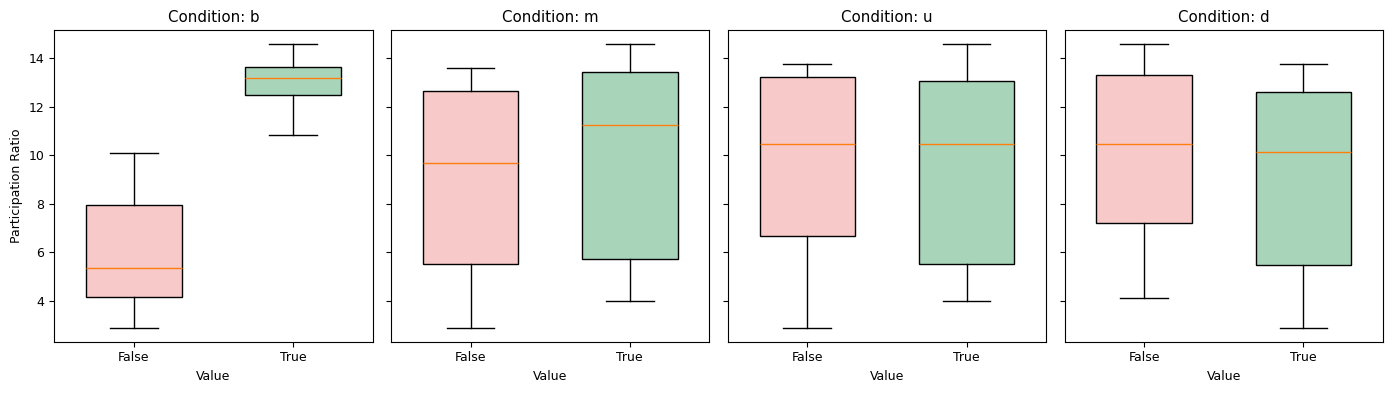

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import re

# ----------------------------------------------------
# Parse boolean condition flags from the names
# ----------------------------------------------------
pattern = re.compile(
    r"e\.b\.los_(True|False)_"
    r"e\.m\.a\.los_(True|False)_"
    r"e\.u\.s\.los_(True|False)_"
    r"e\.d\.los_(True|False)"
)

def extract_bools(s):
    m = pattern.search(s)
    if not m:
        raise ValueError(f"Cannot parse string: {s}")
    return tuple(v == "True" for v in m.groups())

# extract boolean arrays
bools = np.vectorize(extract_bools, otypes=[object])(list_all[0])

# flatten values and conditions
flat_vals = list_all[1].flatten()
flat_bools = np.array(bools.flatten().tolist())

# easier names for the four conditions
cond_names = ["b", "m", "u", "d"]

# ----------------------------------------------------
# Collect data: for each condition, separate True vs False
# ----------------------------------------------------
condition_data = {}

for i, cond in enumerate(cond_names):
    true_vals = flat_vals[flat_bools[:, i] == True]
    false_vals = flat_vals[flat_bools[:, i] == False]

    condition_data[cond] = (true_vals, false_vals)


# ----------------------------------------------------
# Plotting: four subplots, boxplots for True/False
# ----------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)

pastel_true = "#A8D5BA"   # light pastel green
pastel_false = "#F7C9C9"  # light pastel red

for ax, cond in zip(axes, cond_names):
    true_vals, false_vals = condition_data[cond]

    bp = ax.boxplot(
        [false_vals, true_vals],
        labels=["False", "True"],
        patch_artist=True,
        widths=0.6
    )

    # color the boxes
    bp["boxes"][0].set_facecolor(pastel_false)
    bp["boxes"][1].set_facecolor(pastel_true)

    ax.set_title(f"Condition: {cond}")
    ax.set_xlabel("Value")

axes[0].set_ylabel("Participation Ratio")

plt.tight_layout()
plt.show()


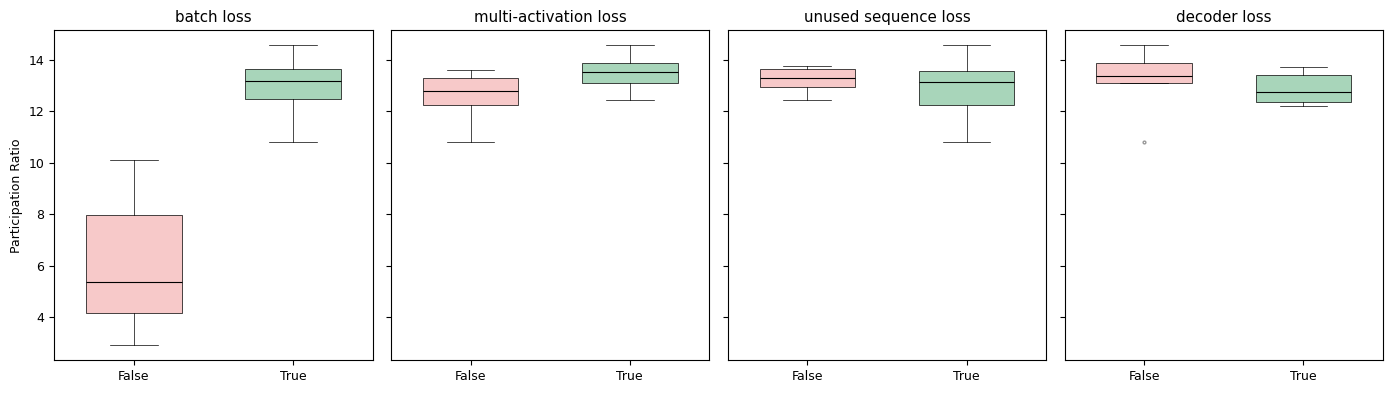

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import re

# ----------------------------------------------------
# Parse boolean condition flags from the names
# ----------------------------------------------------
pattern = re.compile(
    r"e\.b\.los_(True|False)_"
    r"e\.m\.a\.los_(True|False)_"
    r"e\.u\.s\.los_(True|False)_"
    r"e\.d\.los_(True|False)"
)

def extract_bools(s):
    m = pattern.search(s)
    if not m:
        raise ValueError(f"Cannot parse string: {s}")
    return tuple(v == "True" for v in m.groups())

bools = np.vectorize(extract_bools, otypes=[object])(list_all[0])

# flatten arrays
flat_vals = list_all[1].flatten()
flat_bools = np.array(bools.flatten().tolist())

# conditions in order: b, m, u, d
cond_names = ["batch loss", "multi-activation loss", "unused sequence loss", "decoder loss"]

# ----------------------------------------------------
# Build the condition data
# ----------------------------------------------------
condition_data = {}

for i, cond in enumerate(cond_names):

    if cond == "batch loss":
        # Condition b: use ALL values
        true_vals  = flat_vals[flat_bools[:, 0] == True]
        false_vals = flat_vals[flat_bools[:, 0] == False]

    else:
        # Conditions m, u, d: restrict to b == True first
        mask_b_true = (flat_bools[:, 0] == True)

        true_vals  = flat_vals[(flat_bools[:, i] == True)  & mask_b_true]
        false_vals = flat_vals[(flat_bools[:, i] == False) & mask_b_true]

    condition_data[cond] = (true_vals, false_vals)

# ----------------------------------------------------
# Plotting: four subplots, boxplots for True/False
# ----------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)

pastel_true  = "#A8D5BA"   # light pastel green
pastel_false = "#F7C9C9"   # light pastel red

for ax, cond in zip(axes, cond_names):
    true_vals, false_vals = condition_data[cond]

    bp = ax.boxplot(
        [false_vals, true_vals],
        tick_labels=["False", "True"],
        patch_artist=True,
        widths=0.6,
        boxprops=dict(color='k', linewidth=0.5),
        medianprops=dict(color='k', linewidth=0.8),
        whiskerprops=dict(color='k', linewidth=0.5),
        capprops=dict(color='k', linewidth=0.5),
        flierprops=dict(marker='o', markersize=2, alpha=0.4)
    )

    bp["boxes"][0].set_facecolor(pastel_false)
    bp["boxes"][1].set_facecolor(pastel_true)

    ax.set_title(f"{cond}")
    ax.set_xlabel("")

axes[0].set_ylabel("Participation Ratio")

plt.tight_layout()
plt.savefig("loss_participation_ratio.png")
plt.show()


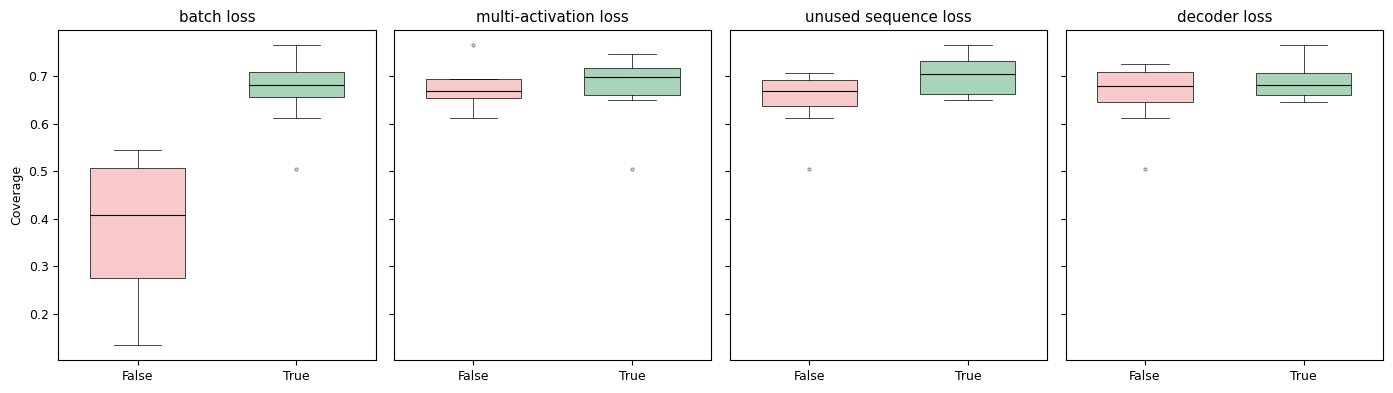

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import re

# ----------------------------------------------------
# Parse boolean condition flags from the names
# ----------------------------------------------------
pattern = re.compile(
    r"e\.b\.los_(True|False)_"
    r"e\.m\.a\.los_(True|False)_"
    r"e\.u\.s\.los_(True|False)_"
    r"e\.d\.los_(True|False)"
)

def extract_bools(s):
    m = pattern.search(s)
    if not m:
        raise ValueError(f"Cannot parse string: {s}")
    return tuple(v == "True" for v in m.groups())

bools = np.vectorize(extract_bools, otypes=[object])(list_all[0])

# flatten arrays
flat_vals = list_all[2].flatten()
flat_bools = np.array(bools.flatten().tolist())

# conditions in order: b, m, u, d
cond_names = ["batch loss", "multi-activation loss", "unused sequence loss", "decoder loss"]

# ----------------------------------------------------
# Build the condition data
# ----------------------------------------------------
condition_data = {}

for i, cond in enumerate(cond_names):

    if cond == "batch loss":
        # Condition b: use ALL values
        true_vals  = flat_vals[flat_bools[:, 0] == True]
        false_vals = flat_vals[flat_bools[:, 0] == False]

    else:
        # Conditions m, u, d: restrict to b == True first
        mask_b_true = (flat_bools[:, 0] == True)

        true_vals  = flat_vals[(flat_bools[:, i] == True)  & mask_b_true]
        false_vals = flat_vals[(flat_bools[:, i] == False) & mask_b_true]

    condition_data[cond] = (true_vals, false_vals)

# ----------------------------------------------------
# Plotting: four subplots, boxplots for True/False
# ----------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)

pastel_true  = "#A8D5BA"   # light pastel green
pastel_false = "#F7C9C9"   # light pastel red

for ax, cond in zip(axes, cond_names):
    true_vals, false_vals = condition_data[cond]
    true_vals = 1- true_vals
    false_vals = 1- false_vals

    bp = ax.boxplot(
        [false_vals, true_vals],
        tick_labels=["False", "True"],
        patch_artist=True,
        widths=0.6,
        boxprops=dict(color='k', linewidth=0.5),
        medianprops=dict(color='k', linewidth=0.8),
        whiskerprops=dict(color='k', linewidth=0.5),
        capprops=dict(color='k', linewidth=0.5),
        flierprops=dict(marker='o', markersize=2, alpha=0.4)
    )

    bp["boxes"][0].set_facecolor(pastel_false)
    bp["boxes"][1].set_facecolor(pastel_true)

    ax.set_title(f"{cond}")
    ax.set_xlabel("")

axes[0].set_ylabel("Coverage")

plt.tight_layout()
plt.savefig("loss_coverage.png")
plt.show()

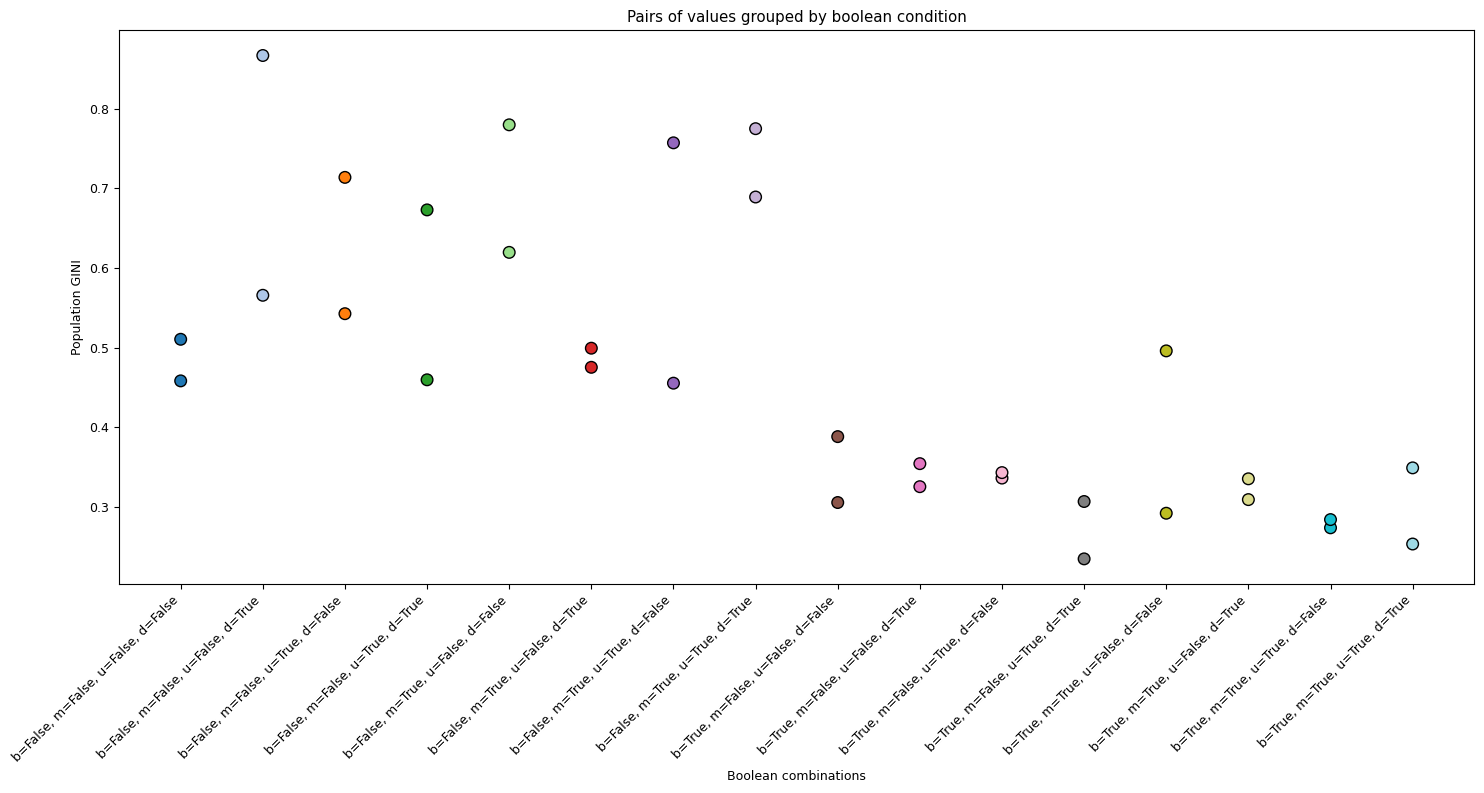

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. Extract the 4 True/False boolean factors
# ----------------------------------------------------

pattern = re.compile(
    r"e\.b\.los_(True|False)_"
    r"e\.m\.a\.los_(True|False)_"
    r"e\.u\.s\.los_(True|False)_"
    r"e\.d\.los_(True|False)"
)

def extract_bools(s):
    m = pattern.search(s)
    if not m:
        raise ValueError(f"Cannot parse string: {s}")
    return tuple(v == "True" for v in m.groups())

arr = np.array(list_all[0])  # your 5D array
bools = np.vectorize(extract_bools, otypes=[object])(arr)
# print(bools)


# ----------------------------------------------------
# 2. Convert each boolean combination to int (0..15)
# ----------------------------------------------------

unique_combos = sorted({c for c in bools.flatten()})
combo_to_int = {combo: i for i, combo in enumerate(unique_combos)}
int_labels = np.vectorize(lambda c: combo_to_int[c])(bools)

flat_bools = np.array(bools.flatten(), dtype=object)
flat_ints = int_labels.flatten()


# ----------------------------------------------------
# 3. Plot: two points per combination at the same x,
#    distinct colors per combination
# ----------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 8))

# x = combination index
x_positions = np.array([combo_to_int[b] for b in flat_bools])

# y = just spread them so you can see the two points clearly
#     (e.g., jitter or fixed two y values)
y_positions = list_all[2]#np.zeros_like(x_positions)
# y_positions += np.linspace(-0.15, 0.15, len(y_positions))  # tiny jitter

scatter = ax.scatter(
    x_positions,
    y_positions,
    c=flat_ints,
    cmap="tab20",
    s=70,
    edgecolor="black"
)


# ----------------------------------------------------
# 4. Meaningful xtick labels
# ----------------------------------------------------

xticks = np.arange(len(unique_combos))
xticklabels = [
    f"b={b}, m={m}, u={u}, d={d}"
    for (b, m, u, d) in unique_combos
]

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=45, ha='right')
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_xlabel("Boolean combinations")
ax.set_ylabel("Population GINI")
# ax.set_yticks([])
ax.set_title("Pairs of values grouped by boolean condition")

plt.tight_layout()
plt.savefig("population ")
plt.show()



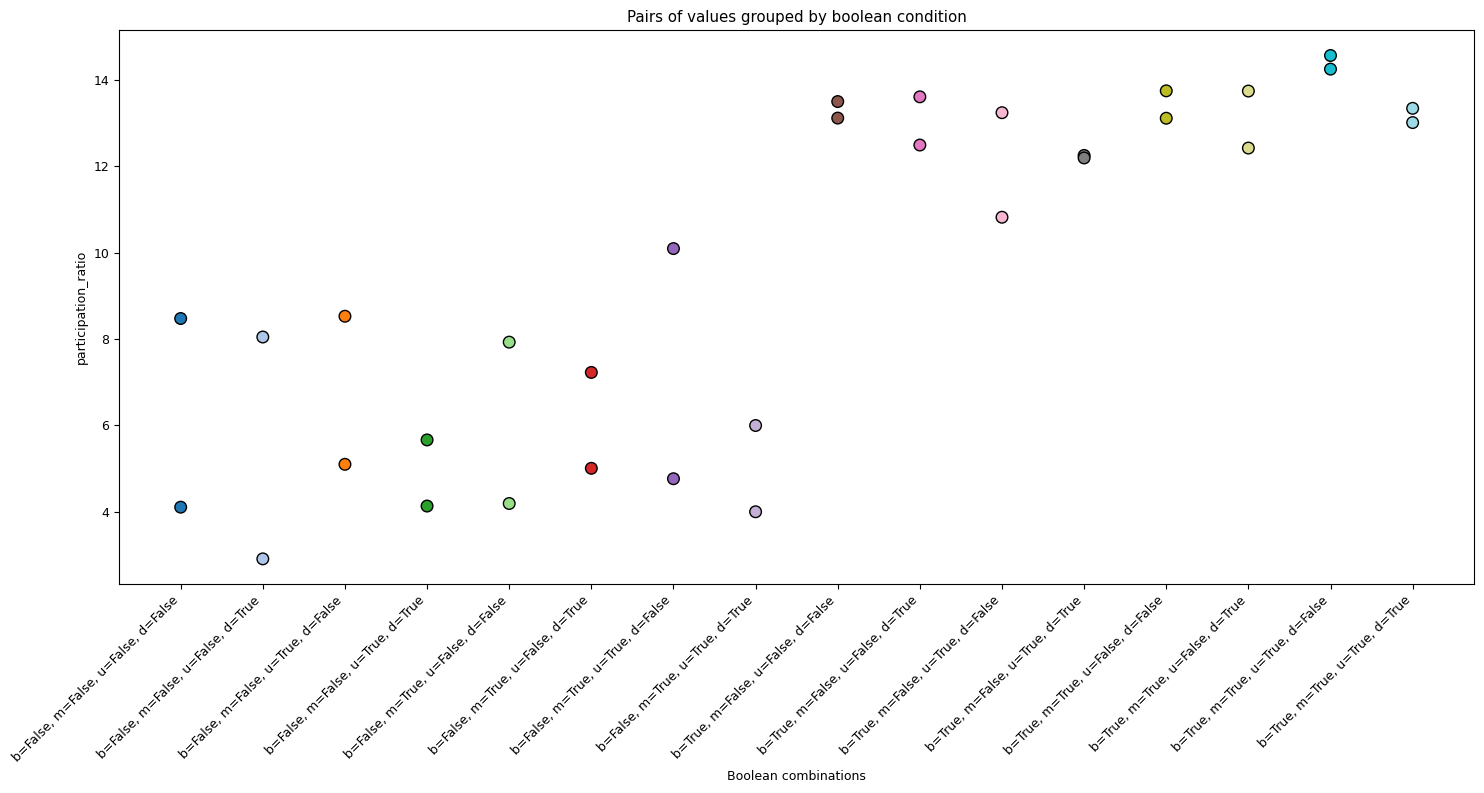

In [21]:
import re
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. Extract the 4 True/False boolean factors
# ----------------------------------------------------

pattern = re.compile(
    r"e\.b\.los_(True|False)_"
    r"e\.m\.a\.los_(True|False)_"
    r"e\.u\.s\.los_(True|False)_"
    r"e\.d\.los_(True|False)"
)

def extract_bools(s):
    m = pattern.search(s)
    if not m:
        raise ValueError(f"Cannot parse string: {s}")
    return tuple(v == "True" for v in m.groups())

arr = np.array(list_all[0])  # your 5D array
bools = np.vectorize(extract_bools, otypes=[object])(arr)


# ----------------------------------------------------
# 2. Convert each boolean combination to int (0..15)
# ----------------------------------------------------

unique_combos = sorted({c for c in bools.flatten()})
combo_to_int = {combo: i for i, combo in enumerate(unique_combos)}
int_labels = np.vectorize(lambda c: combo_to_int[c])(bools)

flat_bools = np.array(bools.flatten(), dtype=object)
flat_ints = int_labels.flatten()


# ----------------------------------------------------
# 3. Plot: two points per combination at the same x,
#    distinct colors per combination
# ----------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 8))

# x = combination index
x_positions = np.array([combo_to_int[b] for b in flat_bools])

# y = just spread them so you can see the two points clearly
#     (e.g., jitter or fixed two y values)
y_positions = list_all[1]#np.zeros_like(x_positions)
# y_positions += np.linspace(-0.15, 0.15, len(y_positions))  # tiny jitter

scatter = ax.scatter(
    x_positions,
    y_positions,
    c=flat_ints,
    cmap="tab20",
    s=70,
    edgecolor="black"
)


# ----------------------------------------------------
# 4. Meaningful xtick labels
# ----------------------------------------------------

xticks = np.arange(len(unique_combos))
xticklabels = [
    f"b={b}, m={m}, u={u}, d={d}"
    for (b, m, u, d) in unique_combos
]

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=45, ha='right')
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_xlabel("Boolean combinations")
ax.set_ylabel("participation_ratio")
# ax.set_yticks([])
ax.set_title("Pairs of values grouped by boolean condition")

plt.tight_layout()
plt.show()



### PF analysis individual

In [14]:
gini_per_neuron = np.array([[0.60435037, 0.6777804 , 0.68181723, 0.67322191, 0.69737767,
       0.75512326, 0.75469523, 0.89078808, 0.66155025, 0.66259592,
       0.76924796, 0.75347115, 0.52769286, 0.63363309, 0.54708819,
       0.76150624], [0.51783092, 0.75524535, 0.68337917, 0.8990589 , 0.90149702,
       0.72289283, 0.75539201, 0.92075075, 0.67945193, 0.72431822,
       0.65844497, 0.84054433, 0.61947338, 0.77626208, 0.62285225,
       0.86999103], [0.7604412 , 0.64558164, 0.71395961, 0.8132595 , 0.45253198,
       0.53502245, 0.67141939, 0.87740296, 0.73401402, 0.72398804,
       0.73067242, 0.67902728, 0.67660839, 0.87957589, 0.56413078,
       0.        ], [0.9375    , 0.7865424 , 0.81585023, 0.61794859, 0.60013217,
       0.52866723, 0.9375    , 0.79076928, 0.9375    , 0.7403791 ,
       0.87553503, 0.60951403, 0.75083331, 0.93127182, 0.78126074,
       0.91269381], [0.6570216 , 0.69420225, 0.93461692, 0.        , 0.92262625,
       0.83598099, 0.7020086 , 0.        , 0.51376601, 0.8658755 ,
       0.81275798, 0.80500275, 0.678688  , 0.6012589 , 0.69697137,
       0.40876052], [0.60959163, 0.5878543 , 0.        , 0.92519744, 0.75263772,
       0.        , 0.63909103, 0.        , 0.83457836, 0.9375    ,
       0.605613  , 0.82877613, 0.74921476, 0.78224853, 0.81739852,
       0.88957598], [0.7471874 , 0.68745916, 0.66761997, 0.696474  , 0.71357365,
       0.80685151, 0.79880273, 0.55147757, 0.77339831, 0.76569505,
       0.82507818, 0.57481614, 0.57920002, 0.        , 0.69217331,
       0.9375    ], [0.60037672, 0.66436702, 0.90999266, 0.8660496 , 0.63499693,
       0.91329281, 0.69983871, 0.        , 0.67745784, 0.60924736,
       0.78398737, 0.66639633, 0.73557392, 0.74254138, 0.53420627,
       0.77582706], [0.70689388, 0.        , 0.        , 0.        , 0.87611693,
       0.        , 0.        , 0.9375    , 0.        , 0.9375    ,
       0.        , 0.9375    , 0.        , 0.        , 0.92578586,
       0.        ], [0.87575678, 0.        , 0.84292708, 0.86385104, 0.8560395 ,
       0.9375    , 0.        , 0.        , 0.7665934 , 0.69581027,
       0.66489623, 0.92900257, 0.        , 0.58614426, 0.72953444,
       0.5570175 ], [0.68387406, 0.        , 0.81374084, 0.        , 0.77974739,
       0.        , 0.        , 0.        , 0.82665632, 0.9375    ,
       0.86310003, 0.70976442, 0.        , 0.        , 0.57366113,
       0.9375    ], [0.81611682, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.91975695, 0.9375    ,
       0.88137731, 0.9375    , 0.9375    , 0.86087787, 0.87534276,
       0.9375    ], [0.66426592, 0.9375    , 0.        , 0.        , 0.9375    ,
       0.        , 0.71229381, 0.        , 0.9375    , 0.        ,
       0.        , 0.9375    , 0.9375    , 0.        , 0.        ,
       0.        ], [0.84191793, 0.        , 0.9375    , 0.        , 0.9375    ,
       0.        , 0.73815404, 0.        , 0.9375    , 0.        ,
       0.        , 0.        , 0.9375    , 0.75248065, 0.76589608,
       0.9375    ], [0.7372442 , 0.        , 0.        , 0.88897439, 0.92236169,
       0.        , 0.        , 0.        , 0.63324018, 0.82268806,
       0.85384329, 0.927215  , 0.        , 0.69944096, 0.92685694,
       0.934187  ], [0.68018017, 0.        , 0.        , 0.        , 0.84239871,
       0.9375    , 0.        , 0.        , 0.88023671, 0.92819057,
       0.9375    , 0.        , 0.        , 0.9375    , 0.81868211,
       0.92074667], [0.9375    , 0.55190971, 0.5729833 , 0.63575425, 0.87129571,
       0.81889337, 0.66077856, 0.9375    , 0.87102117, 0.40972733,
       0.9375    , 0.50138449, 0.        , 0.9375    , 0.52966522,
       0.8748948 ], [0.83442977, 0.53206209, 0.83432952, 0.50048035, 0.64935383,
       0.66589717, 0.74539802, 0.9375    , 0.64666889, 0.47406434,
       0.78960171, 0.52463124, 0.9375    , 0.79317026, 0.52513829,
       0.67491832], [0.9375    , 0.90494304, 0.78460871, 0.72267428, 0.76273406,
       0.57368789, 0.69223919, 0.85654767, 0.58397846, 0.58226202,
       0.71796108, 0.70843331, 0.85541753, 0.48936957, 0.81899087,
       0.69844322], [0.67276143, 0.80749139, 0.65530784, 0.73943241, 0.70767767,
       0.80441718, 0.69180916, 0.92220603, 0.76216812, 0.42713028,
       0.74995452, 0.84780122, 0.80790186, 0.59000907, 0.48643614,
       0.71237482], [0.79851828, 0.49210765, 0.67453847, 0.76195313, 0.56741099,
       0.75341576, 0.74958997, 0.66428581, 0.80670738, 0.87344114,
       0.70631946, 0.70778095, 0.82020148, 0.59879017, 0.67137606,
       0.47814272], [0.9375    , 0.82554501, 0.80371625, 0.42299828, 0.74375355,
       0.88102168, 0.80070942, 0.87518255, 0.        , 0.60027579,
       0.80304668, 0.66059276, 0.866815  , 0.6615378 , 0.63192064,
       0.60917875], [0.9375    , 0.63931932, 0.75095234, 0.7782127 , 0.76552205,
       0.77248854, 0.70783508, 0.9375    , 0.78890203, 0.54599373,
       0.68936609, 0.50979941, 0.91924326, 0.64819003, 0.44256139,
       0.7289824 ], [0.93287187, 0.53704824, 0.9375    , 0.55805169, 0.59469303,
       0.76238054, 0.73758842, 0.89379445, 0.75948187, 0.54416338,
       0.54278486, 0.92100096, 0.9375    , 0.57769513, 0.69187323,
       0.62781047], [0.        , 0.        , 0.9375    , 0.        , 0.9375    ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.9375    , 0.        , 0.        ,
       0.80204147], [0.9375, 0.9375, 0.    , 0.9375, 0.9375, 0.9375, 0.    , 0.9375,
       0.    , 0.    , 0.9375, 0.    , 0.9375, 0.    , 0.9375, 0.    ], [0.        , 0.9375    , 0.58114141, 0.64144791, 0.        ,
       0.        , 0.80032059, 0.        , 0.        , 0.        ,
       0.        , 0.66740773, 0.        , 0.        , 0.5724772 ,
       0.        ], [0.9375    , 0.86709724, 0.        , 0.        , 0.9375    ,
       0.88123885, 0.        , 0.88590294, 0.        , 0.        ,
       0.9375    , 0.        , 0.9375    , 0.        , 0.        ,
       0.57513584], [0.        , 0.        , 0.64006318, 0.57144432, 0.        ,
       0.        , 0.72661985, 0.        , 0.        , 0.89396551,
       0.        , 0.63746008, 0.        , 0.        , 0.56736714,
       0.        ], [0.        , 0.        , 0.88966436, 0.88944053, 0.        ,
       0.        , 0.9375    , 0.        , 0.        , 0.9375    ,
       0.        , 0.7279554 , 0.        , 0.        , 0.9375    ,
       0.82546254], [0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.9375    , 0.        ,
       0.        , 0.        , 0.9375    , 0.        , 0.        ,
       0.89356171], [0.        , 0.        , 0.65444397, 0.60942848, 0.        ,
       0.        , 0.76805362, 0.        , 0.        , 0.        ,
       0.        , 0.59954979, 0.        , 0.        , 0.58053956,
       0.        ]])

In [15]:
gini_per_neuron = gini_per_neuron.reshape(2,2,2,2,2,16)

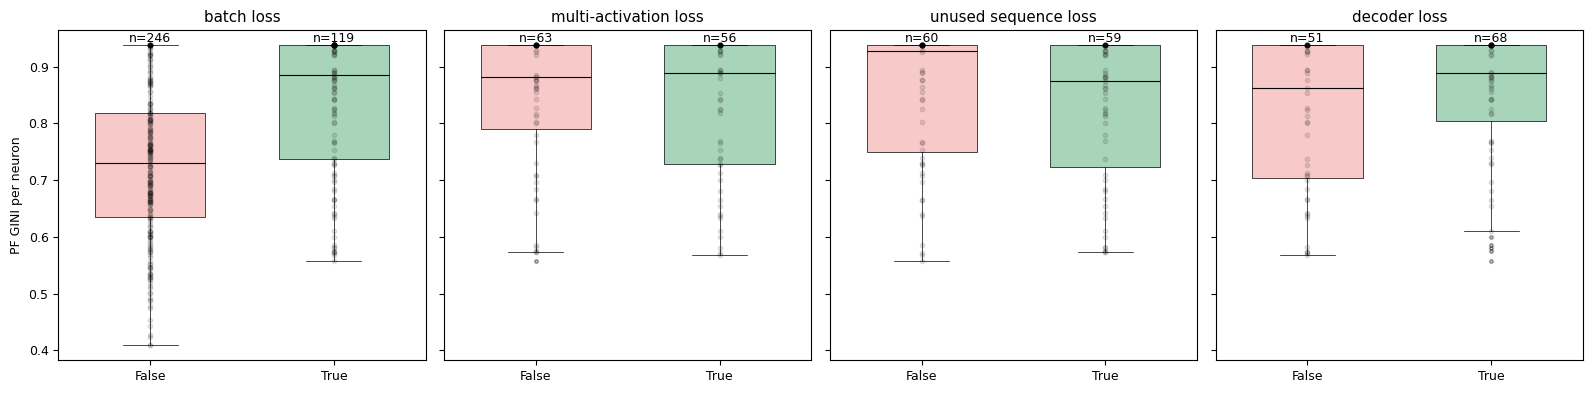

In [18]:
import numpy as np
import matplotlib.pyplot as plt



# ----------------------------------------------------
# Helper function: extract the data for one condition
# ----------------------------------------------------
def get_condition_values(participation_ratio, cond_index, include_b_filter):
    """
    cond_index: 0=b, 1=m, 2=u, 3=d
    include_b_filter: If True, then for m/u/d only include entries where b=True.
    """

    # Unpack shape
    n_seeds, _, _, _, _, n_trials = participation_ratio.shape

    # Flatten seeds and trials into one axis
    # shape → (b, m, u, d, n_samples)
    merged = participation_ratio.reshape(-1, 2, 2, 2, 2, n_trials).transpose(1,2,3,4,0,5)
    merged = merged.reshape(2,2,2,2, -1)   # (b, m, u, d, samples)

    # For the condition of interest
    if cond_index == 0:   # b
        false_vals = merged[0, :, :, :, :].ravel()
        true_vals  = merged[1, :, :, :, :].ravel()

    else:
        if include_b_filter:
            # m, u, d filtered to b=True:
            if cond_index == 1:  # m
                false_vals = merged[1, 0, :, :, :].ravel()
                true_vals  = merged[1, 1, :, :, :].ravel()

            elif cond_index == 2:  # u
                false_vals = merged[1, :, 0, :, :].ravel()
                true_vals  = merged[1, :, 1, :, :].ravel()

            elif cond_index == 3:  # d
                false_vals = merged[1, :, :, 0, :].ravel()
                true_vals  = merged[1, :, :, 1, :].ravel()

        else:
            # No filtering by b
            if cond_index == 1:  # m
                false_vals = merged[:, 0, :, :, :].ravel()
                true_vals  = merged[:, 1, :, :, :].ravel()

            elif cond_index == 2:  # u
                false_vals = merged[:, :, 0, :, :].ravel()
                true_vals  = merged[:, :, 1, :, :].ravel()

            elif cond_index == 3:  # d
                false_vals = merged[:, :, :, 0, :].ravel()
                true_vals  = merged[:, :, :, 1, :].ravel()

    return false_vals, true_vals

# ----------------------------------------------------
# User toggle: include b-filter for m, u, d comparisons
# ----------------------------------------------------
include_b = True   # ← change to False to disable filtering

# ----------------------------------------------------
# Plotting
# ----------------------------------------------------
cond_names = ["batch loss", "multi-activation loss", "unused sequence loss", "decoder loss"]
pastel_false = "#F7C9C9"
pastel_true  = "#A8D5BA"

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for idx, cond in enumerate(cond_names):
    ax = axes[idx]

    false_vals, true_vals = get_condition_values(gini_per_neuron, idx, include_b)
    false_vals = false_vals[false_vals != 0]
    true_vals  = true_vals[true_vals != 0]

    means = [false_vals.mean(), true_vals.mean()]
    sems  = [false_vals.std()/np.sqrt(len(false_vals)),
             true_vals.std()/np.sqrt(len(true_vals))]

    bp = ax.boxplot([false_vals, true_vals], 
                    tick_labels=["False", "True"], 
                    patch_artist=True,
                    widths=0.6,
                    boxprops=dict(color='k', linewidth=0.5),
                    medianprops=dict(color='k', linewidth=0.8),
                    whiskerprops=dict(color='k', linewidth=0.5),
                    capprops=dict(color='k', linewidth=0.5),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4))
    bp["boxes"][0].set_facecolor(pastel_false)
    bp["boxes"][1].set_facecolor(pastel_true)
    # parts = ax.violinplot([false_vals, true_vals], positions=[1,2], showmeans=True)
    # parts['bodies'][0].set_facecolor(pastel_false)
    # parts['bodies'][1].set_facecolor(pastel_true)
    # parts['bodies'][0].set_alpha(0.6)
    # parts['bodies'][1].set_alpha(0.6)
    # ax.set_xticks([1,2])
    # ax.set_xticklabels(["False", "True"])

    # Overlay swarm of individual points
    ax.scatter(np.ones_like(false_vals), false_vals, color="black", alpha=0.1, s=10, zorder=2)
    ax.scatter(np.ones_like(true_vals)*2, true_vals, color="black", alpha=0.1, s=10, zorder=2)

    # Number of non-zero samples
    n_false = np.sum(false_vals != 0)
    n_true  = np.sum(true_vals != 0)

    # Add text above the boxes/violins
    ax.text(1, max(false_vals)*1.001, f"n={n_false}", ha='center', va='bottom', fontsize=9)
    ax.text(2, max(true_vals)*1.001, f"n={n_true}", ha='center', va='bottom', fontsize=9)

    ax.set_title(f"{cond}")
    if idx == 0:
        ax.set_ylabel("PF GINI per neuron" \
        "")

plt.tight_layout()
plt.savefig("loss_gini_per_neuron.png")
plt.show()

In [64]:
pf_netropy_per_neuron = np.array([[0.76424536, 0.69094815, 0.67916397, 0.68583351, 0.66963717,
       0.58976425, 0.58791812, 0.28330448, 0.69464938, 0.69049328,
       0.55682775, 0.54031784, 0.80769892, 0.73325713, 0.78663313,
       0.56440823], [0.82162497, 0.58202268, 0.66975991, 0.23701835, 0.23151794,
       0.62209522, 0.57770631, 0.14662977, 0.68304056, 0.62799362,
       0.69165074, 0.4186637 , 0.73541534, 0.53445713, 0.7359596 ,
       0.3560257 ], [0.56017396, 0.71911554, 0.64065222, 0.48614572, 0.86556818,
       0.811791  , 0.68328401, 0.32619456, 0.61662055, 0.6206052 ,
       0.61657135, 0.67139123, 0.66865819, 0.30772237, 0.79413296,
       0.        ], [-0.        ,  0.52091304,  0.47094499,  0.73956351,  0.76036637,
        0.81695425, -0.        ,  0.48391509, -0.        ,  0.5840744 ,
        0.3324578 ,  0.7506681 ,  0.57601177,  0.07141373,  0.53318772,
        0.17970406], [0.70722668, 0.65007975, 0.03957954, 0.        , 0.13161264,
       0.4345581 , 0.66427209, 0.        , 0.83686724, 0.33887515,
       0.47516673, 0.50721733, 0.68807267, 0.76725557, 0.65728697,
       0.89910667], [ 0.76205386,  0.77656039,  0.        ,  0.11599212,  0.58688494,
        0.        ,  0.73461619,  0.        ,  0.44098805, -0.        ,
        0.73418572,  0.39104667,  0.5962282 ,  0.52633388,  0.46848325,
        0.2805694 ], [ 0.58817333,  0.6695725 ,  0.69157836,  0.65636701,  0.62253414,
        0.46586603,  0.51546259,  0.8027856 ,  0.54346591,  0.54316905,
        0.45173903,  0.77162632,  0.75460602,  0.        ,  0.67187878,
       -0.        ], [0.767495  , 0.69854888, 0.19758738, 0.32618498, 0.71988886,
       0.1782796 , 0.65289494, 0.        , 0.64101605, 0.73545397,
       0.52240409, 0.68905714, 0.59824031, 0.59475573, 0.80980716,
       0.54899654], [ 0.65070436,  0.        ,  0.        ,  0.        ,  0.30217008,
        0.        ,  0.        , -0.        ,  0.        , -0.        ,
        0.        , -0.        ,  0.        ,  0.        ,  0.10485714,
        0.        ], [ 0.3130312 ,  0.        ,  0.42344177,  0.3465992 ,  0.3694158 ,
       -0.        ,  0.        ,  0.        ,  0.55736806,  0.65216898,
        0.70218332,  0.08958441,  0.        ,  0.7770507 ,  0.60976482,
        0.79970873], [ 0.6823647 ,  0.        ,  0.47599875,  0.        ,  0.54133604,
        0.        ,  0.        ,  0.        ,  0.43785656, -0.        ,
        0.34787307,  0.64682145,  0.        ,  0.        ,  0.78064222,
       -0.        ], [ 0.4832896 ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.15358654, -0.        ,
        0.24811914, -0.        , -0.        ,  0.33781967,  0.31130272,
       -0.        ], [ 0.68435115, -0.        ,  0.        ,  0.        , -0.        ,
        0.        ,  0.61986655,  0.        , -0.        ,  0.        ,
        0.        , -0.        , -0.        ,  0.        ,  0.        ,
        0.        ], [ 0.38762011,  0.        , -0.        ,  0.        , -0.        ,
        0.        ,  0.59554396,  0.        , -0.        ,  0.        ,
        0.        ,  0.        , -0.        ,  0.57241247,  0.56731162,
       -0.        ], [0.61178241, 0.        , 0.        , 0.2861017 , 0.13313328,
       0.        , 0.        , 0.        , 0.71249671, 0.46711912,
       0.36323525, 0.10254057, 0.        , 0.66247773, 0.10737235,
       0.04413609], [ 0.65689748,  0.        ,  0.        ,  0.        ,  0.41138567,
       -0.        ,  0.        ,  0.        ,  0.24873249,  0.09560189,
       -0.        ,  0.        ,  0.        , -0.        ,  0.45825571,
        0.14209471], [-0.        ,  0.79651279,  0.77986965,  0.67755053,  0.29149199,
        0.45128162,  0.69548709, -0.        ,  0.30299257,  0.90038725,
       -0.        ,  0.84628596,  0.        , -0.        ,  0.81819598,
        0.3378789 ], [ 0.42236961,  0.81397675,  0.44059196,  0.83130781,  0.70707553,
        0.68588916,  0.58610332, -0.        ,  0.71294418,  0.85713323,
        0.52883732,  0.82294269, -0.        ,  0.50815611,  0.81644962,
        0.6900699 ], [-0.        ,  0.21365192,  0.53498584,  0.62405466,  0.57860449,
        0.78881014,  0.6758731 ,  0.34281991,  0.76022367,  0.76398075,
        0.61933977,  0.64437468,  0.39114202,  0.80898238,  0.42672617,
        0.66395886], [0.68174271, 0.47652084, 0.70539041, 0.60718828, 0.64074861,
       0.47204367, 0.6577405 , 0.13402085, 0.56630975, 0.8843589 ,
       0.59473144, 0.40432113, 0.50124996, 0.76923923, 0.85012685,
       0.63899294], [0.50115259, 0.83541569, 0.66158179, 0.55100248, 0.78313869,
       0.59294645, 0.58059379, 0.69639785, 0.48892127, 0.34063245,
       0.64409037, 0.64682345, 0.4690257 , 0.75716358, 0.69667156,
       0.83598066], [-0.        ,  0.43748083,  0.49770356,  0.87968291,  0.56058244,
        0.31975146,  0.49678692,  0.32611073,  0.        ,  0.75912162,
        0.49403171,  0.70631293,  0.33537179,  0.66280787,  0.73080277,
        0.75206767], [-0.        ,  0.72648223,  0.60010121,  0.55726428,  0.54359985,
        0.52492531,  0.64886644, -0.        ,  0.52899179,  0.80043193,
        0.66204337,  0.82326902,  0.15389677,  0.70130424,  0.8689779 ,
        0.62963506], [ 0.05712048,  0.81149372, -0.        ,  0.79481383,  0.75308715,
        0.5702394 ,  0.58656276,  0.23343752,  0.52737717,  0.78780463,
        0.8101135 ,  0.14063704, -0.        ,  0.78216734,  0.6489594 ,
        0.72113544], [ 0.        ,  0.        , -0.        ,  0.        , -0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        , -0.        ,  0.        ,  0.        ,
        0.49832664], [-0., -0.,  0., -0., -0., -0.,  0., -0.,  0.,  0., -0.,  0., -0.,
        0., -0.,  0.], [ 0.        , -0.        ,  0.78144671,  0.72127962,  0.        ,
        0.        ,  0.49825909,  0.        ,  0.        ,  0.        ,
        0.        ,  0.70386035,  0.        ,  0.        ,  0.7768812 ,
        0.        ], [-0.        ,  0.34556627,  0.        ,  0.        , -0.        ,
        0.24820006,  0.        ,  0.24448385,  0.        ,  0.        ,
       -0.        ,  0.        , -0.        ,  0.        ,  0.        ,
        0.78597261], [0.        , 0.        , 0.72198387, 0.78946443, 0.        ,
       0.        , 0.61446351, 0.        , 0.        , 0.23312973,
       0.        , 0.72580716, 0.        , 0.        , 0.79269382,
       0.        ], [ 0.        ,  0.        ,  0.28922642,  0.24028547,  0.        ,
        0.        , -0.        ,  0.        ,  0.        , -0.        ,
        0.        ,  0.59366842,  0.        ,  0.        , -0.        ,
        0.39324624], [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        , -0.        ,  0.        ,
        0.        ,  0.        , -0.        ,  0.        ,  0.        ,
        0.23385154], [0.        , 0.        , 0.71550105, 0.74905568, 0.        ,
       0.        , 0.55774109, 0.        , 0.        , 0.        ,
       0.        , 0.76586632, 0.        , 0.        , 0.7768171 ,
       0.        ]])
pf_netropy_per_neuron = pf_netropy_per_neuron.reshape((2,2,2,2,2,16))
pf_netropy_per_neuron.shape

(2, 2, 2, 2, 2, 16)

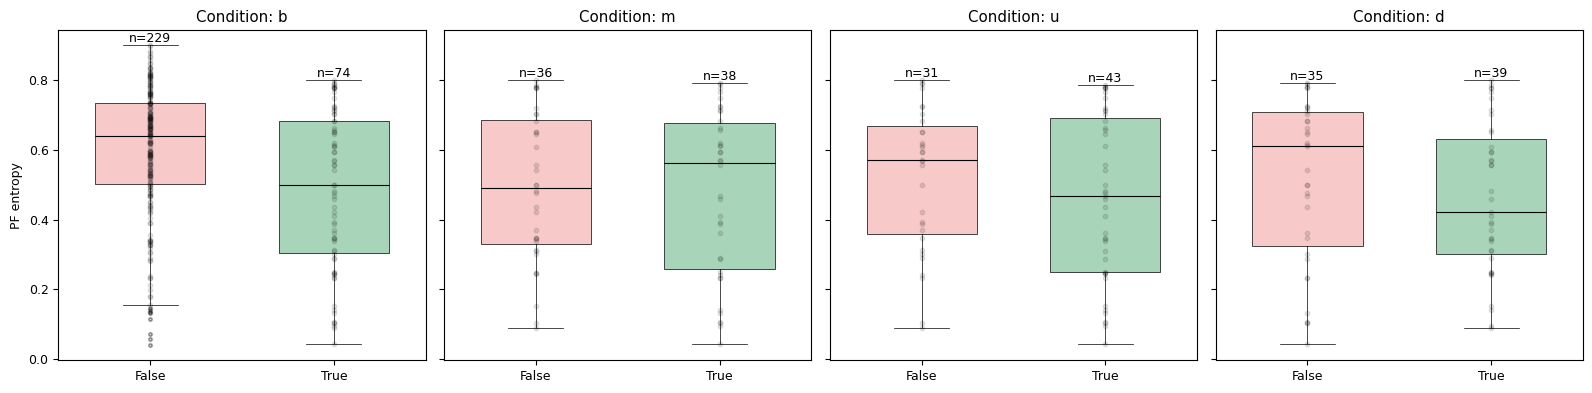

In [115]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# User toggle: include b-filter for m, u, d comparisons
# ----------------------------------------------------
include_b = True   # ← change to False to disable filtering


# ----------------------------------------------------
# Helper function: extract the data for one condition
# ----------------------------------------------------
def get_condition_values(participation_ratio, cond_index, include_b_filter):
    """
    cond_index: 0=b, 1=m, 2=u, 3=d
    include_b_filter: If True, then for m/u/d only include entries where b=True.
    """

    # Unpack shape
    n_seeds, _, _, _, _, n_trials = participation_ratio.shape

    # Flatten seeds and trials into one axis
    # shape → (b, m, u, d, n_samples)
    merged = participation_ratio.reshape(-1, 2, 2, 2, 2, n_trials).transpose(1,2,3,4,0,5)
    merged = merged.reshape(2,2,2,2, -1)   # (b, m, u, d, samples)

    # For the condition of interest
    if cond_index == 0:   # b
        false_vals = merged[0, :, :, :, :].ravel()
        true_vals  = merged[1, :, :, :, :].ravel()

    else:
        if include_b_filter:
            # m, u, d filtered to b=True:
            if cond_index == 1:  # m
                false_vals = merged[1, 0, :, :, :].ravel()
                true_vals  = merged[1, 1, :, :, :].ravel()

            elif cond_index == 2:  # u
                false_vals = merged[1, :, 0, :, :].ravel()
                true_vals  = merged[1, :, 1, :, :].ravel()

            elif cond_index == 3:  # d
                false_vals = merged[1, :, :, 0, :].ravel()
                true_vals  = merged[1, :, :, 1, :].ravel()

        else:
            # No filtering by b
            if cond_index == 1:  # m
                false_vals = merged[:, 0, :, :, :].ravel()
                true_vals  = merged[:, 1, :, :, :].ravel()

            elif cond_index == 2:  # u
                false_vals = merged[:, :, 0, :, :].ravel()
                true_vals  = merged[:, :, 1, :, :].ravel()

            elif cond_index == 3:  # d
                false_vals = merged[:, :, :, 0, :].ravel()
                true_vals  = merged[:, :, :, 1, :].ravel()

    return false_vals, true_vals


# ----------------------------------------------------
# Plotting
# ----------------------------------------------------
cond_names = ["b", "m", "u", "d"]
pastel_false = "#F7C9C9"
pastel_true  = "#A8D5BA"

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for idx, cond in enumerate(cond_names):
    ax = axes[idx]

    false_vals, true_vals = get_condition_values(pf_netropy_per_neuron, idx, include_b)
    false_vals = false_vals[false_vals != 0]
    true_vals  = true_vals[true_vals != 0]

    means = [false_vals.mean(), true_vals.mean()]
    sems  = [false_vals.std()/np.sqrt(len(false_vals)),
             true_vals.std()/np.sqrt(len(true_vals))]

    bp = ax.boxplot([false_vals, true_vals], 
                    tick_labels=["False", "True"], 
                    patch_artist=True,
                    widths=0.6,
                    boxprops=dict(color='k', linewidth=0.5),
                    medianprops=dict(color='k', linewidth=0.8),
                    whiskerprops=dict(color='k', linewidth=0.5),
                    capprops=dict(color='k', linewidth=0.5),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4))
    bp["boxes"][0].set_facecolor(pastel_false)
    bp["boxes"][1].set_facecolor(pastel_true)
    # parts = ax.violinplot([false_vals, true_vals], positions=[1,2], showmeans=True)
    # parts['bodies'][0].set_facecolor(pastel_false)
    # parts['bodies'][1].set_facecolor(pastel_true)
    # parts['bodies'][0].set_alpha(0.6)
    # parts['bodies'][1].set_alpha(0.6)
    # # Make means and extrema black and smaller
    # if parts['cmeans'] is not None:
    #     parts['cmeans'].set_color('black')
    #     parts['cmeans'].set_linewidth(1)

    # if parts['cmins'] is not None:
    #     parts['cmins'].set_color('black')
    #     parts['cmins'].set_linewidth(1)

    # if parts['cmaxes'] is not None:
    #     parts['cmaxes'].set_color('black')
    #     parts['cmaxes'].set_linewidth(1)


    # ax.set_xticks([1,2])
    # ax.set_xticklabels(["False", "True"])

    # Overlay swarm of individual points
    ax.scatter(np.ones_like(false_vals), false_vals, color="black", alpha=0.1, s=10, zorder=2)
    ax.scatter(np.ones_like(true_vals)*2, true_vals, color="black", alpha=0.1, s=10, zorder=2)

    # Number of non-zero samples
    n_false = np.sum(false_vals != 0)
    n_true  = np.sum(true_vals != 0)

    # Add text above the boxes/violins
    ax.text(1, max(false_vals)*1.001, f"n={n_false}", ha='center', va='bottom', fontsize=9)
    ax.text(2, max(true_vals)*1.001, f"n={n_true}", ha='center', va='bottom', fontsize=9)


    ax.set_title(f"Condition: {cond}")
    if idx == 0:
        ax.set_ylabel("PF entropy" \
        "")

plt.tight_layout()
plt.show()


### traj entropy individual

In [19]:
traj_entropy = np.array([[1.1175011 , 1.20565848, 1.3205518 , 1.15113465, 1.16982753,
       1.29820398, 1.14175434, 1.07036502, 1.25290406, 1.25091306,
       0.87734107, 1.34013754, 0.81075992, 1.20273146, 1.30750487,
       1.22225924, 1.21777225, 1.32654433, 1.25511857, 1.17566005,
       1.07124274, 0.90002216, 1.07590704, 1.16560852, 1.12450576,
       1.03486685, 1.24048625, 1.31706171, 0.83770802, 1.22045411,
       0.90842843, 1.07072207, 1.23618141, 1.27081028, 1.23009047,
       1.29189252, 1.16624375, 0.92941938, 1.06357198, 1.2780762 ,
       1.31980671, 1.09321846, 1.30699019, 1.13570892, 0.94649645,
       1.01920108, 1.27713132, 0.93336451, 1.33162416, 1.18055199,
       1.34043759, 0.95222832, 1.34441239, 1.23682299, 1.31549071], [1.32988207, 1.18000506, 1.12649832, 0.90599285, 0.69953239,
       1.00452891, 0.93977262, 1.2412414 , 1.26603751, 1.31527216,
       1.32054435, 1.27320811, 0.98217866, 1.35428936, 1.32039538,
       1.38021439, 1.30649781, 1.07536019, 1.36583283, 1.34753285,
       1.35992195, 1.30668549, 1.25706613, 1.19955394, 1.07261052,
       1.30967972, 1.29026062, 1.06357684, 0.89022267, 1.14230907,
       1.10832629, 1.18959111, 1.36906733, 1.30556069, 1.34169579,
       1.26094172, 1.27425649, 1.26815682, 1.18626759, 0.94039368,
       1.25862607, 1.22204696, 1.05058773, 1.25236656, 1.30378805,
       1.33522665, 1.30692236, 1.30820065, 1.30739805, 1.2496938 ,
       1.0954188 , 1.29433115, 1.21889367, 1.2501882 , 1.29741717], [0.84309026, 0.79602114, 1.05066558, 0.84098595, 0.78614987,
       1.329458  , 1.35852191, 1.30679096, 1.14219562, 1.22201045,
       1.26943258, 1.10306899, 1.01151429, 1.05769568, 1.14424909,
       1.25149767, 1.02104679, 1.17542771, 1.17666434, 1.23693485,
       1.19735019, 1.13267255, 0.86978676, 0.94257491, 0.85662765,
       1.2590011 , 1.3276788 , 1.10722937, 0.62149422, 1.36538133,
       0.81910271, 1.30147614, 1.19338536, 1.30951759, 1.20190593,
       1.17301454, 1.28247705, 1.33758157, 0.93091197, 1.35003317,
       1.1972446 , 1.3687188 , 0.87119591, 1.33335448, 1.24813084,
       0.74742748, 1.35334917, 1.16547141, 1.28574425, 1.11504437,
       0.88451685, 1.24198697, 1.25871544, 1.23405548, 1.0808321 ], [1.27174186, 1.17861787, 1.31145971, 1.31693268, 1.13622382,
       1.32818916, 0.95341807, 1.24945227, 0.90370047, 1.24958253,
       1.31565992, 1.21927221, 1.350183  , 0.88220981, 0.75623466,
       1.22069623, 0.95230868, 1.19545406, 1.18521857, 1.05982735,
       0.89731823, 1.10395589, 1.2523652 , 1.15806244, 1.25462805,
       1.18708324, 1.03851749, 1.02864833, 1.29687391, 1.16439257,
       0.76624576, 1.2525761 , 0.85769663, 1.15496877, 0.7803714 ,
       1.34400411, 0.9698935 , 0.65539576, 0.90565236, 0.75881702,
       0.60958328, 1.24294624, 1.33343519, 0.82053767, 1.18954674,
       1.33815952, 1.07171169, 1.32562902, 0.76633633, 0.73341179,
       1.33446074, 1.19974881, 1.24048792, 1.22292258, 1.288102  ], [0.95402547, 1.00033126, 1.16102724, 1.22363426, 1.22703836,
       1.16678759, 1.13794197, 1.17780722, 1.23816719, 1.12706811,
       1.13597788, 1.3582278 , 1.29965954, 1.31030071, 1.31571231,
       1.0912707 , 1.35349637, 1.37467546, 1.08075449, 1.10548426,
       0.88796838, 1.1102842 , 1.16047006, 1.10387393, 1.23201705,
       0.86442247, 1.23328896, 1.30541733, 1.31742458, 1.23986769,
       1.14424767, 1.24194705, 1.05820458, 1.22378649, 1.13492029,
       1.36890601, 1.05628226, 1.21139792, 1.29103914, 1.1087583 ,
       1.08764224, 1.28576715, 1.20871649, 1.21206286, 1.32002031,
       1.14604692, 1.22096585, 1.01096249, 1.3403875 , 1.30549542,
       1.37015432, 1.10913673, 1.24515755, 1.04520345, 1.22019016], [1.19772396, 1.27392722, 1.10184623, 1.22256267, 1.04893915,
       1.02959321, 0.77051749, 1.06890312, 1.13214756, 0.82693988,
       1.3385997 , 1.08334983, 1.3027983 , 1.20652254, 1.29816393,
       0.98245731, 1.02489367, 0.86630884, 0.76754048, 1.03269694,
       1.07676597, 0.76177812, 1.32453819, 1.30077262, 1.0680127 ,
       0.48784459, 1.27740242, 1.13010527, 1.16410182, 1.19161809,
       1.16721744, 1.20805254, 0.93844575, 1.23446998, 0.8690579 ,
       1.22279416, 1.33979061, 0.99320652, 1.38260567, 1.38022075,
       0.75546181, 1.20596219, 1.13833675, 0.96145799, 1.08631432,
       1.01057687, 1.24555626, 0.98675421, 1.31774006, 0.98882221,
       0.62412234, 0.6634922 , 1.05218204, 1.31298448, 1.36506098], [1.26606439, 1.3011854 , 1.07854113, 1.26290946, 1.24307402,
       0.73431365, 1.27927444, 1.20985397, 1.32463457, 1.27019616,
       1.32013156, 1.04482638, 1.28978458, 1.29630596, 1.28727602,
       1.02007161, 1.15268177, 1.28221027, 0.64170013, 1.17071503,
       1.24814411, 1.31322775, 1.36592186, 0.43063355, 0.86908041,
       1.27684409, 1.24206749, 1.29797821, 1.13022088, 1.36520859,
       1.24246548, 1.22906768, 1.20929529, 1.27818091, 1.03433997,
       1.17330502, 1.139413  , 1.22597942, 0.59514321, 0.89963037,
       1.09445882, 1.35727395, 1.23024716, 1.19320404, 1.26313883,
       0.88974149, 1.29586042, 1.1534234 , 1.35820518, 1.21971573,
       1.32957488, 1.02314961, 1.25973459, 0.87933228, 1.33449651], [1.28496587, 1.18510334, 1.20907192, 1.17059726, 1.12696166,
       1.22847265, 0.72758688, 1.2267733 , 1.06859643, 1.32505209,
       0.9261887 , 1.10504912, 1.09524396, 0.82946008, 1.3360116 ,
       1.36668919, 1.35120951, 1.16206602, 1.35346597, 1.19144764,
       1.33432621, 1.37198285, 1.07686067, 0.93951986, 1.04725052,
       0.8737254 , 1.02356099, 1.23645336, 1.17643632, 0.96496596,
       1.25003493, 1.36438294, 1.27827092, 1.34526901, 1.11451542,
       1.20572398, 1.21345821, 1.22081691, 1.34825067, 0.99748492,
       1.15774483, 1.23836031, 1.36921167, 1.33678469, 1.21346875,
       1.32159358, 1.32818539, 1.24739206, 1.25677867, 1.2937321 ,
       1.33379467, 1.33823966, 1.18926459, 1.20243316, 1.3444875 ], [1.35562335, 1.33937332, 1.22345839, 1.22154099, 1.37181562,
       1.21553911, 1.19228193, 1.3132747 , 1.33973548, 1.18054577,
       1.26904456, 1.12502929, 1.32902174, 1.3692344 , 1.24258615,
       1.27296104, 1.33674504, 1.29184784, 0.95558989, 1.33735934,
       1.23867812, 1.04821086, 0.95892665, 1.25698601, 0.99326994,
       1.26671466, 1.25528934, 1.30065426, 1.28908162, 1.37555923,
       1.38097054, 1.2841564 , 1.29820003, 1.20749526, 1.17998934,
       1.36703875, 1.31539218, 1.35415809, 1.3394471 , 1.21900366,
       1.1391803 , 1.34205529, 1.22635719, 1.36607993, 1.34670865,
       1.3690172 , 1.36432173, 1.06003822, 1.3147013 , 1.19424404,
       1.20526545, 1.2653234 , 1.35241399, 1.31364308, 1.24488582], [1.10341333, 1.04832292, 1.27594568, 1.24359655, 1.33272126,
       0.8531597 , 1.31908425, 1.32944669, 1.37243289, 1.31398154,
       1.02005129, 1.07712087, 1.37214739, 1.24062755, 1.26132812,
       1.34066932, 1.15879504, 1.01348244, 1.26753392, 1.17974004,
       0.97829312, 0.72000305, 1.01491251, 1.0255714 , 1.28522402,
       0.83564303, 1.18188814, 1.19660678, 1.19410161, 1.3249351 ,
       1.13467907, 1.28444322, 1.21826827, 1.14693946, 1.37763039,
       1.28404194, 1.15688767, 1.10768796, 1.37187989, 0.98236606,
       1.10126934, 1.3094378 , 1.30567988, 1.20213157, 1.34952396,
       1.13075719, 1.26368568, 1.10786559, 1.34634562, 1.28444187,
       1.21896822, 1.27669048, 1.35536795, 1.36312097, 1.32347914], [0.97156436, 0.69225092, 1.05790238, 1.05118691, 1.27716952,
       0.92598061, 1.18068835, 1.35905127, 1.29069048, 1.05051255,
       1.10158908, 1.17067716, 1.16192831, 0.88106355, 1.26410423,
       1.24571685, 1.26500182, 1.36812657, 1.30466042, 1.2525191 ,
       1.35776645, 1.26367043, 1.36253116, 1.32968757, 1.16227686,
       1.331476  , 1.28060531, 1.16828208, 1.32190905, 0.88553975,
       1.18479067, 1.30609793, 0.94776771, 1.33999209, 1.0556254 ,
       1.09196628, 1.07554046, 1.35175118, 1.26752061, 1.35604293,
       1.34886754, 0.9428372 , 1.26217462, 1.3239274 , 1.10806866,
       1.29086806, 1.08776979, 1.24644586, 1.19741529, 1.34157046,
       1.37227229, 1.34435409, 1.32030081, 1.37750302, 1.33881195], [1.36694084, 1.18588228, 1.35182813, 1.28624914, 1.229891  ,
       1.30627171, 1.30208518, 1.36576157, 1.29390531, 1.35520951,
       1.3405841 , 1.24549771, 1.30934792, 1.27805186, 1.29740498,
       1.27139622, 1.29185498, 1.28131497, 0.88059724, 1.13553304,
       1.1703692 , 1.29948897, 1.17503438, 1.2134762 , 1.31961078,
       1.28047352, 1.31157575, 1.22241239, 1.3648539 , 1.33026478,
       1.31702894, 1.30402611, 1.18301478, 1.07288572, 1.2341082 ,
       1.3200002 , 0.8638962 , 1.09145599, 1.09721776, 1.16946805,
       1.29201165, 1.23157116, 1.29482488, 1.33213928, 1.19041984,
       1.16622787, 1.23219301, 1.3077992 , 1.20951495, 0.9801894 ,
       1.28376746, 1.15562706, 1.11127542, 1.37368042, 0.73641116], [1.11746734, 1.16691621, 0.90799466, 1.06772287, 1.2666055 ,
       1.36753712, 1.23216199, 1.35053218, 1.03617687, 1.28190359,
       0.939675  , 1.17046001, 1.23548719, 0.78768998, 1.28770077,
       1.29094496, 1.19025458, 0.77524185, 1.34293694, 1.26874341,
       1.10131133, 1.23214563, 1.26869284, 1.17838893, 0.92185249,
       1.30527732, 1.33469467, 1.21605763, 1.23223723, 0.91035952,
       1.07803718, 1.30352314, 1.18055201, 1.18662287, 1.12888245,
       1.13349191, 1.11015896, 1.24904749, 0.81873507, 1.30197343,
       1.33051428, 1.31981512, 1.32738184, 1.31607302, 0.81808312,
       0.93713041, 1.26194755, 1.28965224, 1.38232649, 1.27163894,
       1.31385272, 1.12501262, 1.36402674, 1.30760829, 0.98551676], [1.34915402, 0.99086277, 1.29046307, 1.19558068, 1.18673476,
       1.31921215, 1.11623654, 1.27576102, 1.11801711, 1.24404939,
       1.06589113, 1.36674134, 1.2159104 , 1.3209797 , 1.28918486,
       1.35428303, 1.17555322, 1.34225064, 1.35997046, 1.30390905,
       1.30464412, 1.04786029, 1.21351228, 1.34167625, 0.88893522,
       1.31349408, 0.94655217, 1.33271989, 1.36202054, 1.08577546,
       1.35668127, 1.27963109, 1.12439642, 1.34851361, 0.9890595 ,
       1.26148424, 1.25998844, 1.17493235, 1.37594494, 1.33446792,
       0.69453847, 1.16101403, 1.25790352, 1.06174603, 1.28170791,
       1.13081187, 1.34810457, 1.11359647, 1.03008542, 1.30560748,
       1.3605583 , 1.32620528, 1.31375066, 1.33241102, 1.34929862], [1.09737653, 1.38080095, 1.36357437, 1.08119731, 1.10098429,
       1.12453584, 1.1612989 , 1.31860194, 0.79581384, 1.18625251,
       1.35113624, 1.12702257, 1.27068006, 0.80870557, 0.96646552,
       1.36674607, 1.21613236, 1.33384786, 1.25511102, 0.99623491,
       0.87052808, 1.18250082, 1.22565163, 1.08856946, 1.19251478,
       1.10503017, 1.23254244, 1.14992728, 1.29773146, 1.31021236,
       0.86013617, 1.10444998, 1.18486212, 1.02919975, 1.03762265,
       1.17768266, 1.32632686, 1.10977836, 1.28053453, 0.94941102,
       1.04625609, 0.65208725, 0.95564766, 1.31423138, 0.68620607,
       1.30897024, 1.15952424, 1.11059408, 1.15414622, 1.24606592,
       1.08811789, 1.11799585, 1.19205532, 1.03812179, 1.04070416], [1.17440644, 1.28824423, 1.12432766, 1.07749788, 1.22375763,
       1.27957785, 1.33502223, 1.38133141, 1.19258103, 1.33356694,
       1.31434885, 1.29007996, 1.17395909, 1.28731358, 1.32003314,
       1.17602528, 1.32838881, 1.32740786, 1.35394907, 1.34987833,
       1.37685385, 1.30950604, 1.3652162 , 1.23423824, 0.97979839,
       1.30656715, 1.16338425, 1.31649667, 1.36326567, 1.30204806,
       1.30264903, 1.22111248, 1.22468719, 1.26729014, 1.21984956,
       1.18503945, 1.35588157, 1.20450227, 1.28889609, 1.26751506,
       1.29371649, 1.34147521, 1.23072097, 1.16097787, 1.19943535,
       1.33533474, 1.34955054, 1.28176637, 1.29772267, 1.35459444,
       1.31942861, 1.13967241, 1.15036865, 1.31616756, 0.85257969], [1.35212471, 1.09736047, 1.27590361, 1.28570158, 1.16353953,
       1.10474957, 1.24511643, 0.9818835 , 1.27368044, 1.02059032,
       1.21530997, 1.3082932 , 0.85493773, 1.30185226, 1.36923898,
       1.36716365, 1.19404797, 1.27108422, 1.06460878, 1.08977786,
       1.29239483, 1.24251845, 1.31131202, 1.21446995, 1.33134858,
       1.33797846, 1.26966547, 1.2975629 , 1.11290017, 1.22614951,
       0.95549987, 1.09196628, 1.20211074, 1.21487912, 1.07984942,
       1.18237883, 1.37192897, 1.34677638, 1.10952444, 0.98753314,
       1.17988523, 1.22183013, 1.30416298, 1.07747809, 1.25431397,
       1.27787371, 1.35212426, 1.27682895, 1.36238988, 1.18959838,
       1.26633728, 1.2301439 , 1.21488516, 1.3302188 , 1.2174051 ], [1.00481665, 1.19219321, 1.14134543, 1.28493382, 1.27496118,
       0.93034523, 1.18174867, 1.28337713, 1.27294292, 1.15999317,
       1.36648476, 1.32153846, 0.87717166, 1.30093637, 1.36203905,
       1.35750031, 1.27771589, 1.30326151, 1.30614211, 1.35225665,
       1.1575395 , 1.17046013, 1.23372393, 1.340289  , 1.24969339,
       1.33939063, 1.13652832, 1.29308956, 1.22832338, 1.31470051,
       1.30055323, 1.34469202, 1.31548667, 1.03314879, 1.14813858,
       1.33724858, 1.27916559, 1.22872783, 1.3091197 , 1.35731038,
       1.3312599 , 1.06057181, 1.30855363, 1.20286581, 1.0814062 ,
       1.32869397, 1.27206903, 1.32275414, 1.1368059 , 1.03241065,
       1.13943613, 1.32683783, 1.27185987, 1.29696796, 1.21093122], [1.21036947, 1.09445118, 1.08343147, 1.14269201, 1.27654371,
       1.36831161, 1.25993492, 0.93929287, 1.32345561, 1.30165644,
       1.34093167, 1.36865049, 1.36246943, 1.37542839, 0.93016632,
       1.26431498, 1.26170496, 0.98130635, 1.19729355, 1.29298527,
       1.08959272, 1.17416489, 0.73536887, 1.36373915, 1.34820297,
       1.29129045, 1.04969997, 0.858632  , 1.37472153, 0.98510595,
       1.00700465, 1.06647898, 0.96243461, 0.75771381, 1.20435087,
       1.11093584, 1.16444945, 1.10952055, 1.32780132, 1.24952609,
       1.2501159 , 1.22953942, 1.1065145 , 1.31362889, 1.32253517,
       1.13438507, 1.32287554, 1.14890431, 1.03194254, 1.38470481,
       1.33109679, 1.00399879, 1.10203756, 1.29292093, 1.20628341], [1.35881087, 1.24900913, 1.30804626, 1.26666802, 1.06328932,
       1.07966661, 1.27986882, 1.35039626, 1.36361628, 1.32045775,
       1.00823565, 0.71261583, 0.96272961, 1.22214616, 1.24756416,
       1.06323821, 1.3271002 , 1.28330778, 1.13386462, 1.15300862,
       1.25214576, 1.29128379, 1.22184705, 1.06863495, 1.14252777,
       1.37769289, 1.22136909, 1.27815819, 1.25861427, 1.28468668,
       1.1599894 , 0.75383829, 1.26644775, 1.14168719, 1.31160528,
       1.17096487, 1.16535789, 1.29107623, 1.1671873 , 1.26542781,
       1.25216594, 1.25215174, 1.34503075, 1.10670238, 1.28619248,
       1.2674098 , 1.26424592, 1.33072603, 1.20790663, 1.30300861,
       0.87350093, 1.34300895, 1.23864417, 1.14404281, 1.3247047 ], [0.98071527, 1.13370406, 1.05231136, 1.31832926, 1.32422055,
       1.19001679, 1.16610926, 1.17658854, 0.98719939, 1.23431348,
       1.37331546, 1.29420493, 1.27342411, 1.29659296, 1.37248469,
       1.3197457 , 1.1113533 , 1.19469721, 1.1149147 , 1.30692365,
       1.01744568, 1.20821332, 0.87546694, 1.28248309, 1.27020298,
       1.23335324, 1.10310965, 1.216233  , 1.18279726, 1.1328429 ,
       0.51130663, 1.23051136, 1.27640873, 1.12783133, 1.17170376,
       1.17274869, 1.0799788 , 1.27428572, 1.13062669, 1.12656249,
       0.87719254, 1.35012735, 1.33401021, 1.12325015, 1.33813088,
       1.34027986, 0.9061035 , 1.18759707, 1.27666066, 1.173014  ,
       1.22578109, 0.84832491, 1.08503828, 1.35575395, 1.20752398], [1.2199267 , 1.14312602, 1.31493695, 1.23834367, 1.07487532,
       1.28234847, 1.29984977, 1.32247066, 1.2737924 , 1.1194801 ,
       0.50364062, 1.2654087 , 1.11591221, 1.21481637, 1.13816526,
       1.3008039 , 0.81790599, 0.99996442, 0.97329781, 1.26120624,
       1.25200105, 0.80466083, 1.02829621, 1.33374974, 1.31030865,
       1.05359055, 0.7616523 , 1.30414138, 1.27152954, 0.99750532,
       1.27539347, 0.86166274, 1.00697784, 1.05186174, 0.6795426 ,
       0.63829738, 1.21524699, 1.19900127, 1.02648843, 0.91261658,
       1.01393718, 0.96238419, 1.25863974, 1.27771881, 0.88623331,
       1.27319038, 1.31618154, 0.49271884, 0.93020332, 1.08087992,
       1.32729849, 1.12217121, 1.06950125, 1.3045504 , 1.1456097 ], [1.19365807, 1.35056852, 1.16820128, 1.27115955, 1.32507974,
       1.34239804, 0.99344073, 0.95195867, 1.0889417 , 1.04977907,
       1.34121463, 0.99407945, 1.29470003, 1.25445483, 1.36914316,
       1.3086864 , 1.31735325, 1.15923509, 1.34753147, 1.34474337,
       1.22648946, 1.18386735, 1.27571858, 1.22455102, 1.20530329,
       1.08840949, 1.26437633, 1.29140583, 1.3119208 , 1.22241074,
       1.38125203, 1.2472515 , 1.36586235, 1.09740215, 1.29414444,
       0.98793853, 1.27803812, 1.30508217, 1.10358699, 1.12799719,
       0.76012521, 1.09323248, 0.88937812, 1.22012647, 1.29277082,
       1.33830135, 1.25385142, 1.33348837, 1.31841097, 0.62339023,
       1.16020029, 0.96785402, 1.36634843, 1.233208  , 1.37346534], [1.25759095, 1.07359864, 1.2736214 , 1.21320806, 1.3497629 ,
       1.16760662, 1.25444444, 1.26362455, 1.23075166, 1.32141061,
       1.28188176, 1.30030724, 1.10199748, 1.21686584, 1.33168472,
       1.10838259, 1.3404051 , 0.89665173, 1.38396812, 1.26000401,
       1.36648666, 1.08840765, 1.31461126, 1.24849967, 1.19238195,
       1.30390103, 1.32415021, 1.32324563, 1.2935406 , 1.29158178,
       1.18959778, 1.35736788, 1.31343099, 1.13718677, 1.36547115,
       1.12980112, 0.99175535, 1.245914  , 1.30745451, 1.25260185,
       1.33398052, 0.91453357, 0.94225727, 1.24428839, 1.06830211,
       1.15796634, 1.29806232, 1.34686582, 1.21147971, 1.11984419,
       1.07364763, 1.09876845, 1.31496642, 1.28225266, 1.0859268 ], [1.36086149, 1.28122719, 1.37009018, 1.04658834, 1.27672561,
       0.65501956, 1.37881844, 0.97019958, 1.2431446 , 1.2389225 ,
       1.11660181, 1.36991997, 1.35003335, 1.15902128, 1.33159694,
       1.18681811, 1.03079888, 1.08014412, 1.31587994, 1.33631895,
       1.12231513, 1.36960169, 1.26222694, 1.24710249, 1.30354469,
       0.94236159, 1.30224268, 1.20407009, 1.25319824, 1.37067169,
       1.23149966, 1.11888365, 1.15940797, 1.28471889, 0.88544134,
       1.27145971, 1.31163984, 1.19480583, 1.33514318, 1.16634768,
       1.25878754, 1.29562039, 1.34151623, 1.2795406 , 1.34473199,
       1.1125365 , 1.10841068, 1.1743911 , 1.28100049, 0.57274448,
       1.3473025 , 1.31163153, 1.26569024, 1.05012163, 1.29898753], [1.2834207 , 1.28000779, 1.19101275, 1.27350538, 1.36023976,
       1.31530661, 1.23963803, 1.3614139 , 1.38558241, 1.24581132,
       1.1600364 , 1.26319199, 1.11854874, 0.95530449, 1.31758523,
       1.21560777, 1.05251443, 1.30958244, 1.24873706, 1.09329709,
       1.24413798, 0.88931079, 1.29066802, 1.20048444, 1.10725695,
       1.29121152, 1.03678077, 1.14832112, 1.3702299 , 1.29686851,
       1.29634085, 1.29963559, 1.22802921, 1.35572361, 1.31243268,
       1.20563208, 1.26044732, 1.25773251, 1.320463  , 1.19159404,
       1.36221119, 1.10044836, 1.36338947, 1.37431929, 1.21080246,
       1.13095262, 1.18702492, 1.3410031 , 1.36389812, 1.08125868,
       1.28078535, 1.18422423, 1.22645857, 1.07714843, 1.31121556], [1.01969121, 1.02128359, 1.25040948, 1.31502918, 1.02388911,
       0.83601375, 0.76729682, 1.1841462 , 1.26616905, 1.30516459,
       0.75068532, 1.38063394, 1.03751462, 1.26144483, 1.08014293,
       1.2429723 , 0.79353006, 0.91578879, 0.9360112 , 1.11605825,
       1.01759801, 1.01091674, 1.25903511, 1.17686001, 1.24729176,
       1.2296042 , 1.20521155, 1.28798539, 1.21343909, 1.34483141,
       0.59754973, 1.17601645, 1.3355106 , 1.15532899, 1.15939594,
       1.27051251, 1.13184575, 1.05587508, 1.20074946, 0.83573489,
       1.01897232, 0.95862021, 1.06713189, 1.28492434, 1.06046485,
       1.32200494, 1.26005871, 1.17181532, 1.00825895, 1.31246779,
       0.79729737, 1.29544401, 1.29015928, 1.32948656, 0.99067014], [1.22856591, 1.23491197, 1.27998988, 1.31367036, 1.02727126,
       1.1484065 , 1.32531139, 1.2330886 , 1.14680246, 1.36044245,
       1.35147581, 1.07382918, 1.35551092, 1.30499693, 1.3226329 ,
       1.35933041, 0.64457721, 1.32460468, 1.2200015 , 1.31100089,
       1.28077871, 1.27760193, 1.32255442, 1.22073524, 1.22496392,
       1.37357403, 0.91175284, 1.1791645 , 1.20075369, 1.09201693,
       1.34853234, 1.20977917, 1.00123145, 1.09765072, 1.38253592,
       1.3412245 , 1.19568357, 1.21368691, 1.19691557, 1.06238317,
       1.26366863, 1.32437348, 1.01276241, 1.25226176, 1.05358181,
       1.03665743, 1.08828686, 1.32146093, 1.1171013 , 1.1860866 ,
       1.27420575, 1.27560489, 1.20535317, 1.38343897, 1.1813554 ], [0.75052155, 1.03936253, 1.03131244, 1.1485032 , 1.16350126,
       1.0463536 , 0.89075977, 0.81557204, 0.97531523, 1.19581714,
       0.83748294, 0.84461028, 1.03370128, 1.36694084, 0.6363798 ,
       1.20504614, 1.29093631, 0.96675456, 1.33094599, 1.05774755,
       1.16139002, 1.25075645, 0.83084729, 1.27994374, 1.21988213,
       1.2959308 , 1.29647136, 1.28994014, 1.2889592 , 1.2266216 ,
       1.23299977, 1.37714688, 1.29148118, 1.26360561, 1.04772797,
       1.02035272, 1.13545471, 0.71805603, 0.79901771, 1.2759993 ,
       1.34130104, 1.17707404, 1.25105077, 1.13631585, 1.2922084 ,
       1.23515742, 0.79938563, 0.2178727 , 1.08441032, 1.0861652 ,
       1.2425352 , 1.11184107, 1.09358566, 1.34434491, 1.23585901], [1.14274986, 1.2091355 , 1.14067329, 1.14707239, 1.00795843,
       1.36946308, 1.20382228, 1.10161017, 1.10141591, 1.22387886,
       1.35997622, 1.22372009, 1.23629413, 0.76803985, 1.08703189,
       1.26931729, 1.03870225, 0.97578089, 1.17061979, 0.67040499,
       1.29234478, 0.86087497, 0.76871085, 1.20272002, 1.0543636 ,
       0.9943858 , 1.21352007, 1.31693268, 1.16682623, 1.15107314,
       1.34049398, 1.02453434, 1.35200716, 1.29152075, 1.30172282,
       1.23593582, 1.25563011, 1.35587095, 1.04867818, 1.04302783,
       1.29973316, 1.05665487, 1.14050464, 1.09277952, 1.23719573,
       1.21132347, 1.26637431, 1.02333637, 1.23406126, 1.17886864,
       1.28760908, 1.2264066 , 1.33219416, 1.26942854, 1.28513601], [0.71079395, 1.13683572, 1.15735135, 1.05059945, 1.18793602,
       0.91819489, 0.87954556, 1.34287016, 0.99229023, 0.6926268 ,
       1.14212556, 1.33607609, 1.13859404, 1.32616092, 1.32094313,
       1.20413401, 1.19184915, 1.07980342, 1.34023123, 1.27280749,
       1.27139712, 1.34760983, 1.07365952, 1.30574462, 1.09788405,
       1.30021638, 1.27707213, 1.29855403, 1.1020548 , 1.35888532,
       1.14449177, 1.37403978, 1.22870374, 1.33440904, 1.07644762,
       1.26624998, 0.81271166, 1.26228805, 1.3430813 , 0.98127133,
       1.06316871, 0.81346034, 1.25223029, 1.28884252, 1.31347558,
       1.187167  , 1.34060401, 1.34156378, 1.00236016, 1.09679463,
       1.03467491, 0.83796482, 1.33207626, 1.22360802, 1.36644089], [1.0557087 , 1.36313921, 1.12966525, 1.01677499, 1.1516829 ,
       0.82655598, 1.28722485, 1.26075316, 0.8365294 , 1.16204471,
       1.2193778 , 0.9653186 , 1.02966784, 0.69300798, 0.77575157,
       0.22408075, 1.23255121, 0.97220679, 1.20886361, 1.2386182 ,
       1.17381796, 1.30133303, 1.30360483, 1.09781992, 1.25821421,
       1.05633371, 1.08822488, 1.15558108, 1.34444854, 1.26994173,
       1.15781871, 1.26664506, 1.21315223, 1.32099392, 1.2357221 ,
       1.34428933, 1.36959462, 1.38034743, 0.94169986, 1.1709605 ,
       1.11962595, 1.20451564, 1.07769413, 0.89108217, 1.02191227,
       1.0296752 , 1.31288685, 1.05059471, 1.12135331, 1.28752135,
       1.32904815, 1.26497949, 1.15037662, 0.85621614, 0.98299032]])

In [20]:
traj_entropy = traj_entropy.reshape((2,2,2,2,2,55))

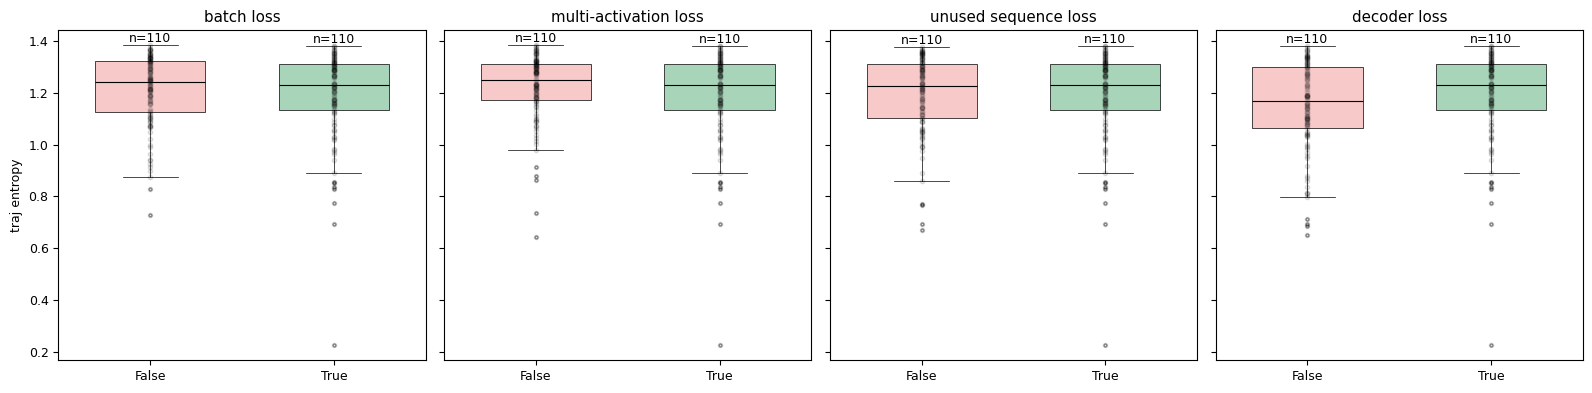

In [22]:
import numpy as np
import matplotlib.pyplot as plt



# ----------------------------------------------------
# Helper function: extract the data for one condition
# ----------------------------------------------------
def get_condition_values(participation_ratio, cond_index, include_b_filter):
    """
    cond_index: 0=b, 1=m, 2=u, 3=d
    include_b_filter: If True, then for m/u/d only include entries where b=True.
    """

    # Unpack shape
    n_seeds, _, _, _, _, n_trials = participation_ratio.shape

    # Flatten seeds and trials into one axis
    # shape → (b, m, u, d, n_samples)
    merged = participation_ratio.reshape(-1, 2, 2, 2, 2, n_trials).transpose(1,2,3,4,0,5)
    merged = merged.reshape(2,2,2,2, -1)   # (b, m, u, d, samples)

    # For the condition of interest
    if cond_index == 0:   # b
        false_vals = merged[0, :, :, :, :].ravel()
        true_vals  = merged[1, :, :, :, :].ravel()

    else:
        if include_b_filter:
            # m, u, d filtered to b=True:
            if cond_index == 1:  # m
                false_vals = merged[1, 0, :, :, :].ravel()
                true_vals  = merged[1, 1, :, :, :].ravel()

            elif cond_index == 2:  # u
                false_vals = merged[1, :, 0, :, :].ravel()
                true_vals  = merged[1, :, 1, :, :].ravel()

            elif cond_index == 3:  # d
                false_vals = merged[1, :, :, 0, :].ravel()
                true_vals  = merged[1, :, :, 1, :].ravel()

        else:
            # No filtering by b
            if cond_index == 1:  # m
                false_vals = merged[:, 0, :, :, :].ravel()
                true_vals  = merged[:, 1, :, :, :].ravel()

            elif cond_index == 2:  # u
                false_vals = merged[:, :, 0, :, :].ravel()
                true_vals  = merged[:, :, 1, :, :].ravel()

            elif cond_index == 3:  # d
                false_vals = merged[:, :, :, 0, :].ravel()
                true_vals  = merged[:, :, :, 1, :].ravel()

    return false_vals, true_vals

def get_condition_fixed_true(participation_ratio, cond_index):
    """
    Extract False/True values for a given condition while keeping all other conditions True.
    cond_index: 0=b, 1=m, 2=u, 3=d
    """
    n_seeds, _, _, _, _, n_trials = participation_ratio.shape
    # merge seeds and trials
    merged = participation_ratio.reshape(n_seeds, 2,2,2,2,n_trials).transpose(1,2,3,4,0,5)
    merged = merged.reshape(2,2,2,2,-1)  # (b,m,u,d,samples)

    # Indices of other conditions fixed to True
    b_idx = 1 if cond_index != 0 else slice(None)
    m_idx = 1 if cond_index != 1 else slice(None)
    u_idx = 1 if cond_index != 2 else slice(None)
    d_idx = 1 if cond_index != 3 else slice(None)

    false_vals = merged[
        0 if cond_index==0 else b_idx,
        0 if cond_index==1 else m_idx,
        0 if cond_index==2 else u_idx,
        0 if cond_index==3 else d_idx,
        :
    ].ravel()

    true_vals = merged[
        1 if cond_index==0 else b_idx,
        1 if cond_index==1 else m_idx,
        1 if cond_index==2 else u_idx,
        1 if cond_index==3 else d_idx,
        :
    ].ravel()

    return false_vals, true_vals


# ----------------------------------------------------
# User toggle: include b-filter for m, u, d comparisons
# ----------------------------------------------------
include_b = False   # ← change to False to disable filtering

# ----------------------------------------------------
# Plotting
# ----------------------------------------------------
cond_names = ["batch loss", "multi-activation loss", "unused sequence loss", "decoder loss"]
pastel_false = "#F7C9C9"
pastel_true  = "#A8D5BA"

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for idx, cond in enumerate(cond_names):
    ax = axes[idx]

    # false_vals, true_vals = get_condition_values(traj_entropy, idx, include_b)
    false_vals, true_vals = get_condition_fixed_true(traj_entropy, idx)
    false_vals = false_vals[false_vals != 0]
    true_vals  = true_vals[true_vals != 0]

    means = [false_vals.mean(), true_vals.mean()]
    sems  = [false_vals.std()/np.sqrt(len(false_vals)),
             true_vals.std()/np.sqrt(len(true_vals))]

    bp = ax.boxplot([false_vals, true_vals], 
                    tick_labels=["False", "True"], 
                    patch_artist=True,
                    widths=0.6,
                    boxprops=dict(color='k', linewidth=0.5),
                    medianprops=dict(color='k', linewidth=0.8),
                    whiskerprops=dict(color='k', linewidth=0.5),
                    capprops=dict(color='k', linewidth=0.5),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4))
    bp["boxes"][0].set_facecolor(pastel_false)
    bp["boxes"][1].set_facecolor(pastel_true)
    # parts = ax.violinplot([false_vals, true_vals], positions=[1,2], showmeans=True)
    # parts['bodies'][0].set_facecolor(pastel_false)
    # parts['bodies'][1].set_facecolor(pastel_true)
    # parts['bodies'][0].set_alpha(0.6)
    # parts['bodies'][1].set_alpha(0.6)
    # # Make means and extrema black and smaller
    # if parts['cmeans'] is not None:
    #     parts['cmeans'].set_color('black')
    #     parts['cmeans'].set_linewidth(1)

    # if parts['cmins'] is not None:
    #     parts['cmins'].set_color('black')
    #     parts['cmins'].set_linewidth(1)

    # if parts['cmaxes'] is not None:
    #     parts['cmaxes'].set_color('black')
    #     parts['cmaxes'].set_linewidth(1)


    # ax.set_xticks([1,2])
    # ax.set_xticklabels(["False", "True"])

    # Overlay swarm of individual points
    ax.scatter(np.ones_like(false_vals), false_vals, color="black", alpha=0.1, s=10, zorder=2)
    ax.scatter(np.ones_like(true_vals)*2, true_vals, color="black", alpha=0.1, s=10, zorder=2)

    # Number of non-zero samples
    n_false = np.sum(false_vals != 0)
    n_true  = np.sum(true_vals != 0)

    # Add text above the boxes/violins
    ax.text(1, max(false_vals)*1.001, f"n={n_false}", ha='center', va='bottom', fontsize=9)
    ax.text(2, max(true_vals)*1.001, f"n={n_true}", ha='center', va='bottom', fontsize=9)


    ax.set_title(f"{cond}")
    if idx == 0:
        ax.set_ylabel("traj entropy" \
        "")

plt.tight_layout()
plt.savefig("loss_traj.png")
plt.show()